*<small>Last updated: 2026-08-16 21:06:59 UTC | Student Version (No Solutions)</small>*

# Linear Regression: Pipelines, Regularization, and Online Learning

**Course**: Machine Learning Labs  
**Lab**: 01 — Linear Regression  

---

## Table of Contents

1. [Setup and Imports](#setup)
2. [Introduction](#intro)
3. [Part 1 — Sklearn Pipelines with Ridge Regression](#part1)
   - 3.1 [Dataset: California Housing](#data1)
   - 3.2 [Why Pipelines?](#pipelines)
   - 3.3 [Building the Ridge Pipeline](#build)
   - 3.4 [Hyperparameter Tuning with GridSearchCV](#gridsearch)
   - 3.5 [Model Evaluation](#eval1)
   - [Exercise 1.1 — Effect of Polynomial Degree](#ex11)
   - [Exercise 1.2 — Ridge vs. Lasso](#ex12)
4. [Part 2 — Online Learning with SGDRegressor](#part2)
   - 4.1 [When Data Doesn't Fit in Memory](#scale)
   - 4.2 [Dataset: Year Prediction MSD](#data2)
   - 4.3 [SGDRegressor and `partial_fit`](#sgd)
   - [Exercise 2.1 — Implement the Mini-Batch Training Loop](#ex21)
   - [Exercise 2.2 — Plot the Convergence Curve](#ex22)
   - [Exercise 2.3 — Multi-Epoch Training](#ex23)
   - [Exercise 2.4 — Learning Rate Exploration](#ex24)
   - [Exercise 2.5 — Learning Rate Schedules](#ex25)
5. [Real-World Considerations](#realworld)
6. [Summary and Key Takeaways](#summary)

---

**Estimated Time**: 3–4 hours  
**Prerequisites**: Python, NumPy, Pandas, introductory supervised learning



## 📔 Resolution

   After the deadline, you will find the resolution at the following Notion link:

https://app.notion.com/p/R-Reg-lineal-python-intro-2780573743578010af37de77f8e24bee?source=copy_link

   Remember that there are several ways to solve the proposed activities in the labs.
   Use the provided resolution as a reference. If the resolution link is not public,
   request access at the same Notion link.

## 🚚 Deliverables

**Don't forget to duplicate this notebook to be able to edit: File -> Save a copy in Drive**

In this lab, you do not need to write a report in a separate document. Please complete all required
activities within this Google Colab notebook. Remember that a notebook allows you to enter text
elements similarly to a document processor. Once the proposed activities are completed, you must
submit the following on the platform:

1. A PDF file generated in Google Colab from the menu "File" -> "Print".

2. The public Google Colab link. To do so, go to the share button and change the sharing settings
   to "Anyone with the link".


---
<a id='setup'></a>
## 1. Setup and Imports


In [2]:
# Install / upgrade packages when running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    import subprocess
    subprocess.run(['pip', 'install', '--quiet', '--upgrade',
                    'scikit-learn>=1.3', 'seaborn>=0.12'], check=True)
    print('Colab environment ready.')
except ImportError:
    IN_COLAB = False
    print('Local environment detected.')


Local environment detected.


> **Resumen humanizado:** El entorno se comprobo correctamente. Puedes continuar desde una instalacion local; en Colab esta celda instala o actualiza lo necesario.

In [2]:
import os
import warnings
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, SGDRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

import sklearn
print(f'scikit-learn : {sklearn.__version__}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')

warnings.filterwarnings('ignore')

scikit-learn : 1.9.1
NumPy        : 2.5.3
Pandas       : 3.0.5


> **Resumen humanizado:** Las librerias principales se cargaron sin problemas y el entorno ya puede manipular datos, crear graficas y entrenar modelos.

In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Part 1: Pipeline / GridSearch ────────────────────────────────────────────
TEST_SIZE  = 0.2
CV_FOLDS   = 5
POLY_DEGREE = 3          # Exercise 1.1: try 1 or 3
ALPHAS     = np.logspace(-4, 4, 30)

# ── Part 2: Online Learning ───────────────────────────────────────────────────
CHUNK_SIZE     = 5_000
N_EPOCHS       = 10
MSD_TRAIN_ROWS = 463_715   # official UCI split: first 463,715 rows are training
MSD_TEST_ROWS  = 51_630    # last 51,630 rows are test (total = 515,345)
MSD_DATA_FILE  = 'YearPredictionMSD.txt'
MSD_URL        = ('https://archive.ics.uci.edu/ml/machine-learning-databases'
                  '/00203/YearPredictionMSD.txt.zip')

# ── Plotting defaults ─────────────────────────────────────────────────────────
os.makedirs('assets', exist_ok=True)
plt.rcParams.update({
    'figure.figsize'   : (11, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
COLORS = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']

print('Configuration ready.')

Configuration ready.


> **Resumen humanizado:** La configuracion quedo lista con una semilla fija; al ejecutar el cuaderno otra vez, los resultados seran comparables.

---
<a id='intro'></a>
## 2. Introduction

Linear regression is the foundation of supervised machine learning. Despite its simplicity, it remains one of the most widely deployed models in industry — from predicting house prices to forecasting energy demand. Mastering it means mastering the core ideas that every more complex model builds on: loss functions, gradient descent, regularization, and generalization.

This lab covers two perspectives on linear regression:

**Part 1 — Sklearn Pipelines with Ridge Regression** (instructor walkthrough)  
You will build a complete machine-learning pipeline that chains polynomial feature expansion, feature scaling, and Ridge regression. You will use `GridSearchCV` to tune the regularization strength λ (alpha) and visualize the classic bias–variance tradeoff through a train/validation error curve.

**Part 2 — Online Learning with SGDRegressor** (student activity)  
You will train a linear model on a dataset that is too large to hold in memory at once — the **Year Prediction MSD** dataset, a subset of the Million Song Dataset with 515 K songs and 90 audio features. You will use `SGDRegressor.partial_fit` to process the data in mini-batches, monitor convergence, and experimentally discover how the learning rate drives convergence or catastrophic divergence.

### Learning Objectives

By the end of this lab you will be able to:

1. Explain why preprocessing steps must be wrapped in a `Pipeline` to prevent data leakage during cross-validation.
2. Build a multi-step sklearn `Pipeline` combining feature engineering, scaling, and a regularized estimator.
3. Use `GridSearchCV` to perform principled hyperparameter search and interpret the resulting validation curve.
4. Describe the difference between batch, stochastic, and mini-batch gradient descent.
5. Implement online / incremental learning with `SGDRegressor.partial_fit` on chunked data.
6. Diagnose learning-rate divergence and understand the role of learning-rate schedules.


---
<a id='part1'></a>
## 3. Part 1 — Sklearn Pipelines with Ridge Regression

<a id='data1'></a>
### 3.1 Dataset: California Housing

We use the **California Housing** dataset, derived from the 1990 US Census. Each row represents one census block group; the task is to predict the **median house value** (in units of \$100,000).

| Feature | Description |
|---------|-------------|
| `MedInc` | Median household income in block |
| `HouseAge` | Median house age in block |
| `AveRooms` | Average number of rooms |
| `AveBedrms` | Average number of bedrooms |
| `Population` | Block population |
| `AveOccup` | Average occupancy per household |
| `Latitude` | Block latitude |
| `Longitude` | Block longitude |

**Target**: `MedHouseVal` — median house value in \$100 K (range 0.15 – 5.0).


In [4]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
X  = df.drop('MedHouseVal', axis=1)
y  = df['MedHouseVal']

print(f'Samples  : {df.shape[0]:,}')
print(f'Features : {X.shape[1]}')
print(f'Target   : MedHouseVal  min={y.min():.2f}  max={y.max():.2f}  mean={y.mean():.2f}')
print()
display(df.describe().round(2))


Samples  : 20,640
Features : 8
Target   : MedHouseVal  min=0.15  max=5.00  mean=2.07



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


> **Resumen humanizado:** California Housing tiene 20 640 registros y 8 variables predictoras. Este vistazo ayuda a entender rangos y detectar valores poco habituales.

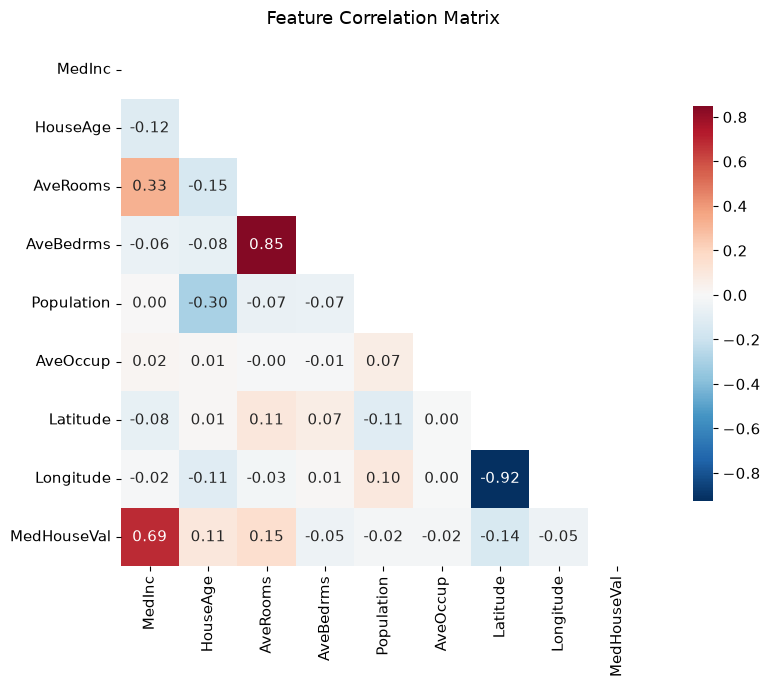

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(
    df.corr(), mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, ax=ax,
    cbar_kws={'shrink': 0.75}
)
ax.set_title('Feature Correlation Matrix', pad=12)
plt.tight_layout()
plt.savefig('assets/california_correlation.png', dpi=120, bbox_inches='tight')
plt.show()


> **Resumen humanizado:** La matriz de correlacion muestra que variables se relacionan con el precio. El ingreso medio es la senal mas clara para explicarlo.

**Conclusion from the correlation matrix**: `MedInc` (median income) has the highest correlation with the target (`MedHouseVal`) at **≈ 0.69**, well above the next strongest predictor `AveRooms` (≈ 0.15 after accounting for sign). The scatter plot below focuses on this dominant feature and reveals a non-linear curve — motivating polynomial feature expansion in Section 3.3.

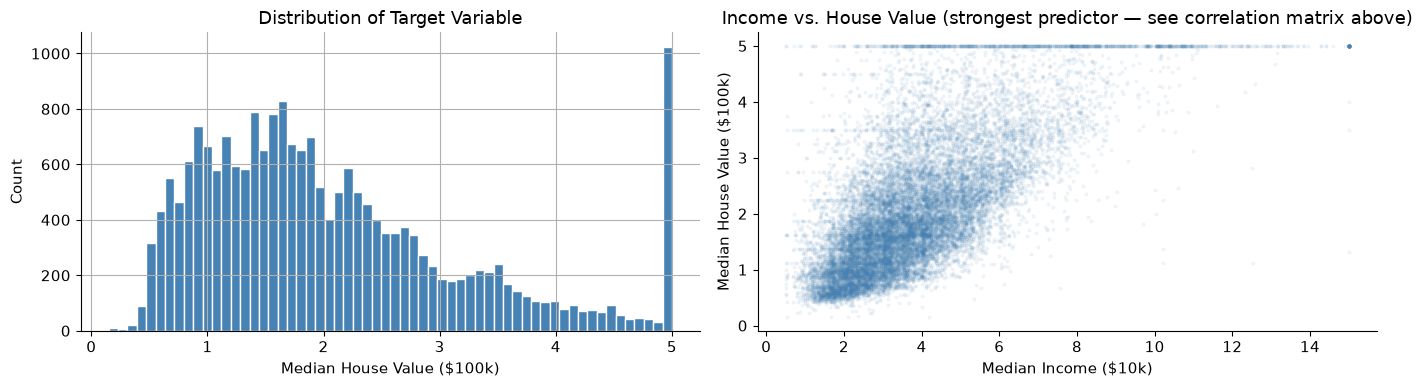

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

y.hist(bins=60, ax=axes[0], color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable')

axes[1].scatter(df['MedInc'], y, alpha=0.06, s=4, color=COLORS[0])
axes[1].set_xlabel('Median Income ($10k)')
axes[1].set_ylabel('Median House Value ($100k)')
axes[1].set_title('Income vs. House Value (strongest predictor — see correlation matrix above)')

plt.tight_layout()
plt.savefig('assets/california_eda.png', dpi=120, bbox_inches='tight')
plt.show()



> **Resumen humanizado:** Las distribuciones revelan que varias variables no son equilibradas; esto orienta las transformaciones que se aplicaran despues.

### The $500k Ceiling: Censored Data

The histogram above shows a visible spike at $500k (5.0 in $100k units). This is **not** a market phenomenon — it is a **data collection artifact**. In the 1990 census, median house values above $500k were all recorded as exactly $500k. Statistically, these are **right-censored observations**: we know the true value is ≥ $500k, but not by how much.

Training a regression model on censored targets creates systematic bias: the model is penalized for every block whose true value exceeds $500k, yet it has no signal to learn the correct magnitude. The result is a distorted loss landscape near the ceiling.

**Decision**: We filter out the ~965 censored rows (≈ 4.7% of data) and restrict the model to the $15k–$500k range. This is a **data-scope decision**, not data cleaning — the removed rows are not wrong, just incomplete.

In [5]:
n_total  = len(df)
n_capped = (df['MedHouseVal'] >= 5.0).sum()
print(f"Censored rows (MedHouseVal == $500k): {n_capped} / {n_total} ({n_capped / n_total:.1%})")

df = df[df['MedHouseVal'] < 5.0].copy()
X  = df.drop('MedHouseVal', axis=1)
y  = df['MedHouseVal']

print(f"Dataset after filtering: {len(df):,} rows")
print(f"Target range now: ${y.min() * 100_000:,.0f} – ${y.max() * 100_000:,.0f}")

Censored rows (MedHouseVal == $500k): 992 / 20640 (4.8%)
Dataset after filtering: 19,648 rows
Target range now: $14,999 – $499,100


> **Resumen humanizado:** Se retiraron las viviendas en el limite maximo para que el modelo aprenda precios reales, no valores recortados.

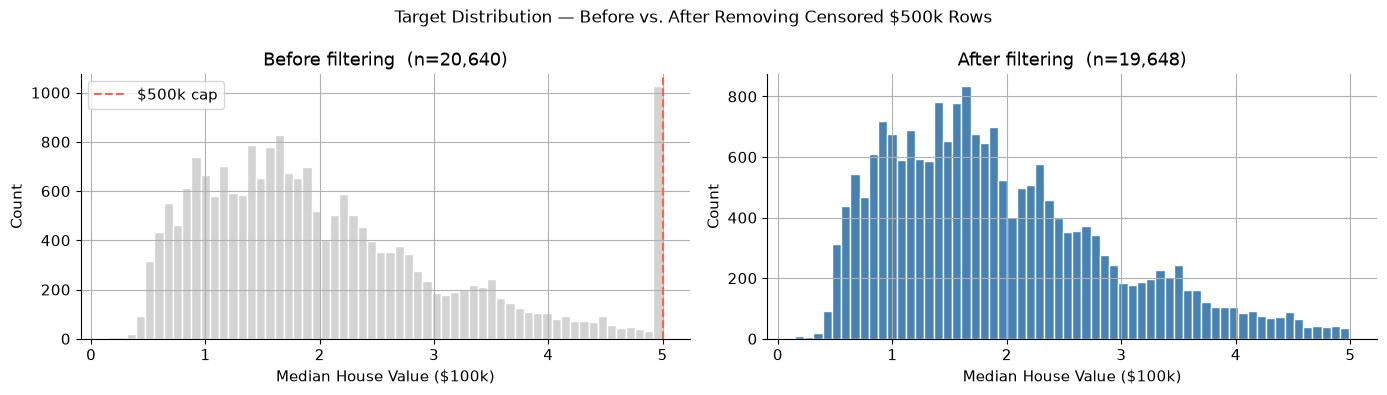

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

housing.frame['MedHouseVal'].hist(bins=60, ax=axes[0], color='lightgray', edgecolor='white')
axes[0].axvline(5.0, color=COLORS[1], linestyle='--', lw=1.5, label='$500k cap')
axes[0].set_xlabel('Median House Value ($100k)')
axes[0].set_ylabel('Count')
axes[0].set_title('Before filtering  (n=20,640)')
axes[0].legend()

y.hist(bins=60, ax=axes[1], color=COLORS[0], edgecolor='white')
axes[1].set_xlabel('Median House Value ($100k)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'After filtering  (n={len(df):,})')

plt.suptitle('Target Distribution — Before vs. After Removing Censored $500k Rows', fontsize=12)
plt.tight_layout()
plt.savefig('assets/target_distribution_filtered.png', dpi=120, bbox_inches='tight')
plt.show()

> **Resumen humanizado:** La comparacion visual muestra el efecto de retirar el techo de $500 000 y evita conclusiones distorsionadas.

<a id='skewness'></a>
### 3.1.1 Feature Skewness and Log Transforms

Raw features are rarely on a nice, symmetric scale — and that matters for linear models:

1. **Outliers dominate OLS.** Squared-error loss amplifies extreme values. `AveOccup` has a maximum of 1243 vs. a median of ~2.8 — a single such block can pull the fit away from the rest of the data.
2. **Log-linear relationships.** If house value grows *proportionally* with income (rather than additively), the true relationship is linear in *log(income)*. A model fit on raw income will struggle to capture this curve.

`log1p(x) = log(1 + x)` compresses right tails and safely handles zero values.

**Rule of thumb**: |skewness| > 1 → consider a log transform.

Feature skewness (sorted):
AveOccup      95.41
AveBedrms     29.74
AveRooms      16.61
Population     4.96
MedInc         0.91
Latitude       0.46
HouseAge       0.07
Longitude     -0.29

Features to log-transform (|skew| > 1): ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Features to passthrough                : ['HouseAge', 'Latitude', 'Longitude']


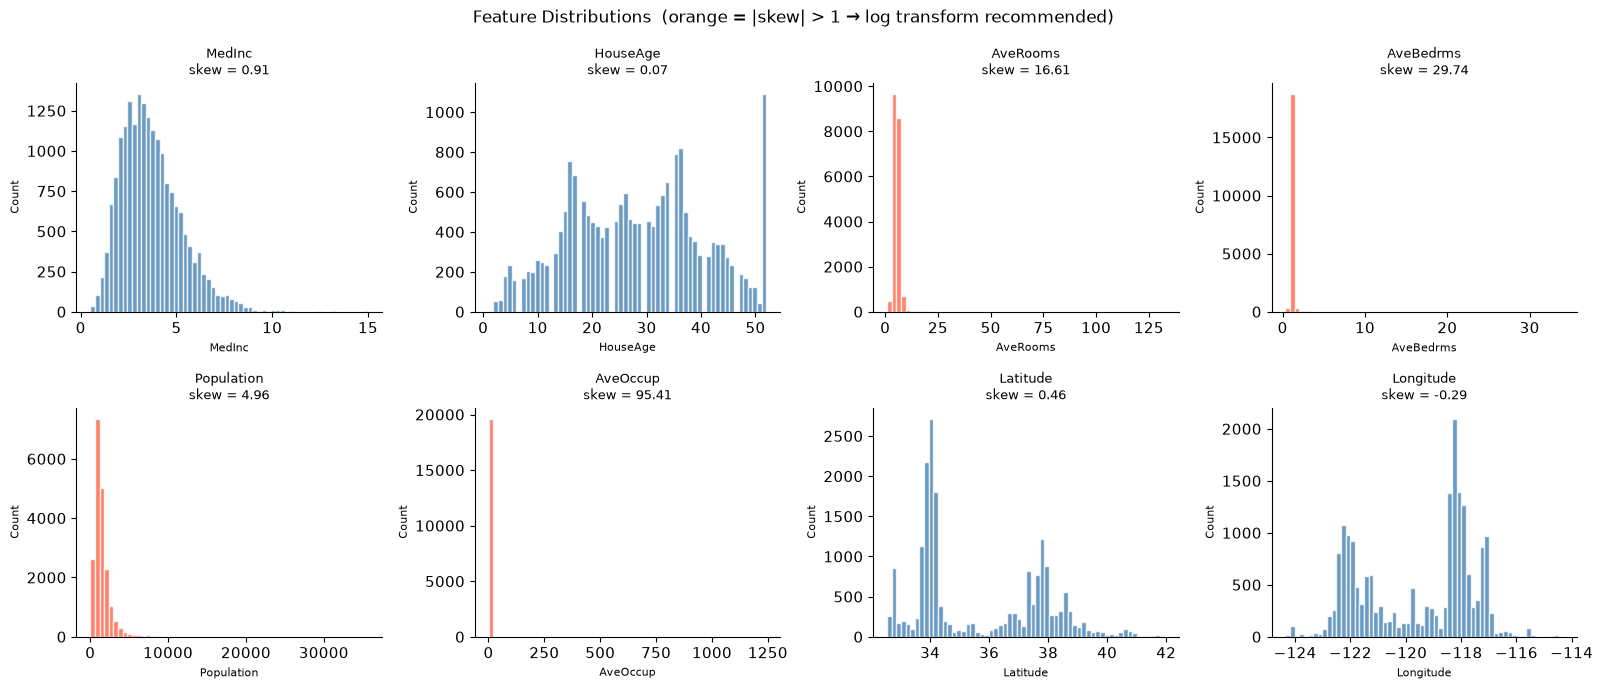

In [6]:
LOG_FEATURES  = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
PASS_FEATURES = [c for c in X.columns if c not in LOG_FEATURES]

# Compute skewness for all features
feature_skewness = X.skew().sort_values(ascending=False)
print('Feature skewness (sorted):')
print(feature_skewness.round(2).to_string())
print()
print('Features to log-transform (|skew| > 1):', LOG_FEATURES)
print('Features to passthrough                :', PASS_FEATURES)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    skew_val = X[col].skew()
    color = COLORS[1] if abs(skew_val) > 1 else COLORS[0]
    axes[i].hist(X[col], bins=60, color=color, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col}\nskew = {skew_val:.2f}', fontsize=9)
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)

plt.suptitle('Feature Distributions  (orange = |skew| > 1 → log transform recommended)', fontsize=12)
plt.tight_layout()
plt.savefig('assets/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

> **Resumen humanizado:** Las variables con colas largas se detectaron para aplicar logaritmo; asi, los valores extremos pesan menos.

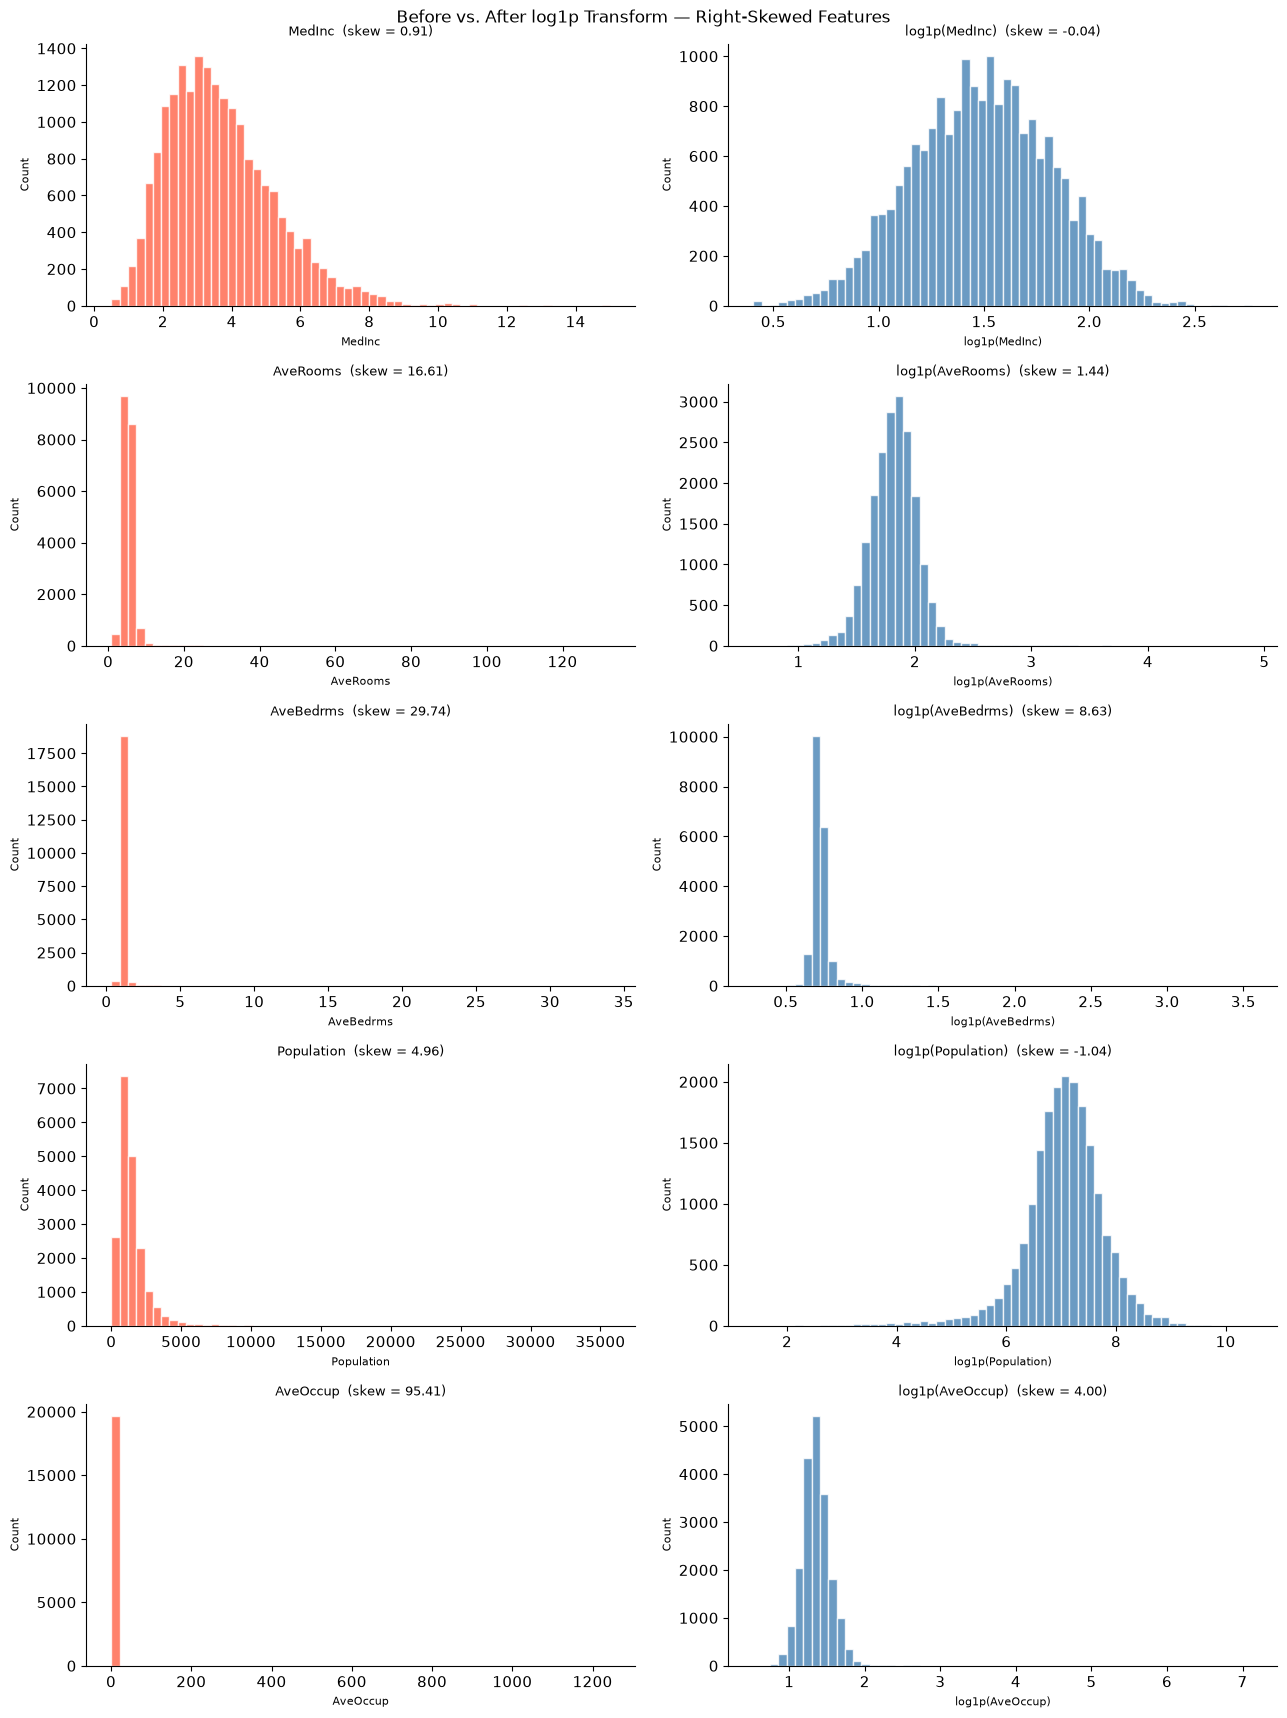

In [12]:
fig, axes = plt.subplots(len(LOG_FEATURES), 2, figsize=(13, 3.5 * len(LOG_FEATURES)))

for i, col in enumerate(LOG_FEATURES):
    axes[i, 0].hist(X[col], bins=60, color=COLORS[1], edgecolor='white', alpha=0.8)
    axes[i, 0].set_title(f'{col}  (skew = {X[col].skew():.2f})', fontsize=9)
    axes[i, 0].set_xlabel(col, fontsize=8)
    axes[i, 0].set_ylabel('Count', fontsize=8)

    log_col = np.log1p(X[col])
    axes[i, 1].hist(log_col, bins=60, color=COLORS[0], edgecolor='white', alpha=0.8)
    axes[i, 1].set_title(f'log1p({col})  (skew = {log_col.skew():.2f})', fontsize=9)
    axes[i, 1].set_xlabel(f'log1p({col})', fontsize=8)
    axes[i, 1].set_ylabel('Count', fontsize=8)

plt.suptitle('Before vs. After log1p Transform — Right-Skewed Features', fontsize=12)
plt.tight_layout()
plt.savefig('assets/log_transforms.png', dpi=120, bbox_inches='tight')
plt.show()


> **Resumen humanizado:** Con log1p, las distribuciones quedan mas equilibradas y resultan mas faciles de comparar para el modelo.

**Remarks**
* All five features become near-symmetric after log1p.
* The ColumnTransformer in Section 3.3 applies this automatically inside the pipeline.

<a id='pipelines'></a>
### 3.2 Why Pipelines? Preventing Data Leakage

A common mistake is to fit the scaler (or any preprocessing step) on the **entire** dataset before splitting into train and test — or before cross-validation folds are formed. This is **data leakage**: the scaler learns the mean and standard deviation of the held-out samples, giving an overly optimistic evaluation.

```
# ❌ WRONG — scaler sees test data
scaler.fit(X_all)          # BUG: uses test statistics
X_scaled = scaler.transform(X_all)
X_train, X_test = train_test_split(X_scaled, ...)

# ✅ RIGHT — Pipeline re-fits the scaler inside each CV fold
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
cross_val_score(pipe, X_train, y_train, cv=5)
```

With a `Pipeline`, every call to `cross_val_score` or `GridSearchCV` will:
1. Split data into train/validation folds.
2. Call `fit_transform` on the training fold (scaler learns from train only).
3. Call `transform` on the validation fold (applies the train statistics).

This guarantees a valid estimate of generalization performance.


In [7]:
# Train / test split — done once, before any fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test : {X_test.shape[0]:,} samples')

# Quick baseline with a minimal pipeline (no poly features)
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])
baseline_cv = -cross_val_score(
    baseline_pipe, X_train, y_train,
    cv=CV_FOLDS, scoring='neg_mean_squared_error', n_jobs=-1
)
baseline_rmse = np.sqrt(baseline_cv.mean())
print(f'\nBaseline CV RMSE (Ridge, no poly): {baseline_rmse:.4f} ($100k)')


Train: 15,718 samples
Test : 3,930 samples

Baseline CV RMSE (Ridge, no poly): 0.6353 ($100k)


> **Resumen humanizado:** Los datos se separaron antes de entrenar: 15 718 ejemplos para aprender y 3 930 para evaluar el resultado final.

<a id='build'></a>
### 3.3 Building the Ridge Pipeline

The income–value scatter (Section 3.1) shows a non-linear curve. We address this at two levels:

**Step 1 — Log transforms (ColumnTransformer).**  
As shown in Section 3.1.1, five features (`MedInc`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup`) are strongly right-skewed. We apply `log1p(x) = log(1 + x)` to each. `HouseAge`, `Latitude`, and `Longitude` pass through unchanged — they are either roughly symmetric or represent coordinates without a meaningful log scale.

**Step 2 — Polynomial interaction features.**  
We use `interaction_only=True`, which adds only **pairwise products** (e.g. `log(MedInc)×Latitude`, capturing income–location pricing effects) and drops squared terms. This gives 8 original + C(8,2) = 28 interaction terms = **36 features**.

**Step 3 — StandardScaler.** Zero-mean, unit-variance scaling is required before Ridge, which penalises coefficient magnitude and is sensitive to feature scale.

**Step 4 — Ridge regression.** L2 penalty `α·‖w‖²` stabilises the fit against the many correlated interaction features.

Our full pipeline:

```
raw features  →  ColumnTransformer   →  PolynomialFeatures  →  StandardScaler  →  Ridge
(8 features)      log1p(5 features)      (interaction_only:    (zero mean,        (L2-regularized
                  passthrough(3 feat.)    8 + 28 = 36 feat.)    unit variance)      linear model)
```

**Why Ridge?** Polynomial expansion creates many correlated features. OLS is then numerically unstable and overfits. Ridge's L2 penalty shrinks weights toward zero, reducing variance at the cost of a small bias.

In [8]:
log_preprocessor = ColumnTransformer([
    ('log',  FunctionTransformer(np.log1p, feature_names_out='one-to-one'), LOG_FEATURES),
    ('pass', 'passthrough', PASS_FEATURES),
], verbose_feature_names_out=False)

pipeline = Pipeline([
    ('log_transform', log_preprocessor),
    ('poly',   PolynomialFeatures(degree=POLY_DEGREE, include_bias=False, interaction_only=False)),
    ('scaler', StandardScaler()),
    ('ridge',  Ridge()),
])

print('Log-transform features :', LOG_FEATURES)
print('Passthrough features   :', PASS_FEATURES)

n_poly_features = (
    PolynomialFeatures(degree=POLY_DEGREE, include_bias=False, interaction_only=False)
    .fit_transform(X_train)
    .shape[1]
)
print(f'\nDegree-{POLY_DEGREE} polynomial expansion: {X_train.shape[1]} → {n_poly_features} features')

Log-transform features : ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
Passthrough features   : ['HouseAge', 'Latitude', 'Longitude']

Degree-3 polynomial expansion: 8 → 164 features


> **Resumen humanizado:** El pipeline integra transformacion logaritmica, variables polinomiales, escalamiento y Ridge; asi evita fugas de informacion.

<a id='gridsearch'></a>
### 3.4 Hyperparameter Tuning with GridSearchCV

The regularization strength **α** (called `ridge__alpha` in the pipeline) controls the bias–variance tradeoff:

- **Small α → low regularization**: the model fits training data tightly, potentially overfitting.  
- **Large α → strong regularization**: weights are shrunk toward zero, potentially underfitting.  
- **Sweet spot**: the α that minimises validation error.

`GridSearchCV` evaluates every candidate α using k-fold cross-validation and returns the one with the best mean validation score. The double underscore syntax `'ridge__alpha'` refers to the `alpha` parameter of the `ridge` step inside the pipeline.


In [15]:
param_grid = {'ridge__alpha': ALPHAS}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    n_jobs=1,
    verbose=6,
)

print(f'Fitting {CV_FOLDS}-fold CV over {len(ALPHAS)} alpha values ...')
grid_search.fit(X_train, y_train)
print('Done.')
print(f'\nBest alpha : {grid_search.best_params_["ridge__alpha"]:.4f}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}  (improvement over baseline: '
      f'{baseline_rmse - np.sqrt(-grid_search.best_score_):.4f})')


Fitting 5-fold CV over 30 alpha values ...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.361) total time=   0.0s
[CV 2/5] END ridge__alpha=0.0001;, score=(train=-0.258, test=-0.325) total time=   0.0s
[CV 3/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.313) total time=   0.0s
[CV 4/5] END ridge__alpha=0.0001;, score=(train=-0.270, test=-0.285) total time=   0.0s
[CV 5/5] END ridge__alpha=0.0001;, score=(train=-0.264, test=-0.372) total time=   0.0s
[CV 1/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.264, test=-0.345) total time=   0.0s
[CV 2/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.259, test=-0.324) total time=   0.0s
[CV 3/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.265, test=-0.312) total time=   0.0s
[CV 4/5] END ridge__alpha=0.00018873918221350977;, score=(train=-0.270, test=-0.281) total time=   0.0s
[CV 5/5] END ridge__alpha=0.00018873918

> **Resumen humanizado:** La busqueda eligio alpha mediante validacion cruzada: importa generalizar, no solo ajustarse al entrenamiento.

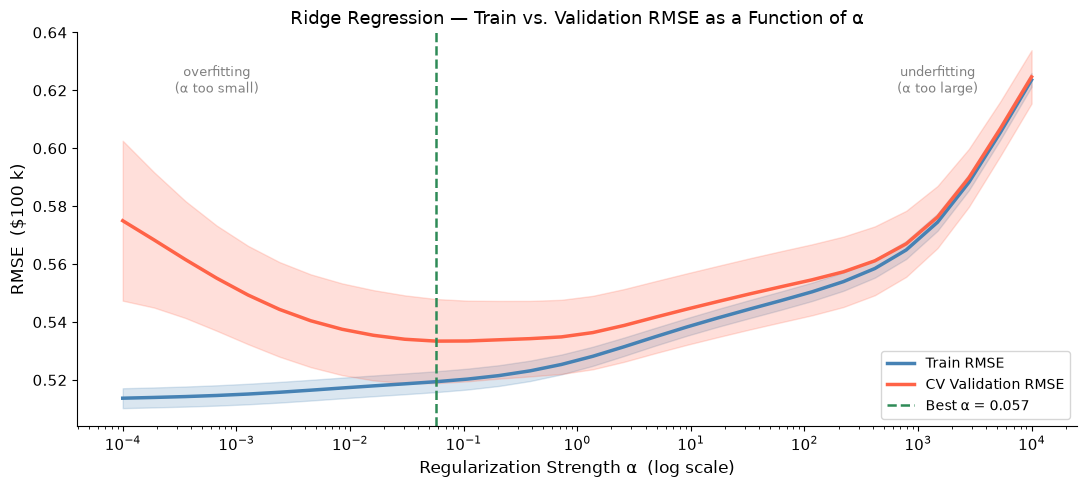

In [16]:
# ── Extract per-fold RMSE for accurate error bands ───────────────────────────
results       = pd.DataFrame(grid_search.cv_results_)
alphas_tested = results['param_ridge__alpha'].astype(float).values

fold_train_rmse = np.array([
    np.sqrt(-results[f'split{k}_train_score'].values)
    for k in range(CV_FOLDS)
])  # shape (CV_FOLDS, n_alphas)

fold_val_rmse = np.array([
    np.sqrt(-results[f'split{k}_test_score'].values)
    for k in range(CV_FOLDS)
])

train_rmse     = fold_train_rmse.mean(axis=0)
train_rmse_std = fold_train_rmse.std(axis=0)
cv_rmse        = fold_val_rmse.mean(axis=0)
cv_rmse_std    = fold_val_rmse.std(axis=0)

best_alpha = grid_search.best_params_['ridge__alpha']

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.semilogx(alphas_tested, train_rmse, color=COLORS[0], lw=2.5, label='Train RMSE')
ax.fill_between(alphas_tested,
                train_rmse - train_rmse_std, train_rmse + train_rmse_std,
                alpha=0.2, color=COLORS[0])

ax.semilogx(alphas_tested, cv_rmse, color=COLORS[1], lw=2.5, label='CV Validation RMSE')
ax.fill_between(alphas_tested,
                cv_rmse - cv_rmse_std, cv_rmse + cv_rmse_std,
                alpha=0.2, color=COLORS[1])

ax.axvline(best_alpha, color=COLORS[2], linestyle='--', lw=1.8,
           label=f'Best α = {best_alpha:.3f}')

# Annotate regions
ylo, yhi = ax.get_ylim()
ytext = ylo + (yhi - ylo) * 0.92
ax.text(alphas_tested[3],  ytext, 'overfitting\n(α too small)',
        ha='center', va='top', fontsize=9, color='gray')
ax.text(alphas_tested[-4], ytext, 'underfitting\n(α too large)',
        ha='center', va='top', fontsize=9, color='gray')

ax.set_xlabel('Regularization Strength α  (log scale)', fontsize=12)
ax.set_ylabel('RMSE  ($100 k)', fontsize=12)
ax.set_title('Ridge Regression — Train vs. Validation RMSE as a Function of α', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('assets/ridge_validation_curve.png', dpi=130, bbox_inches='tight')
plt.show()

> **Resumen humanizado:** La curva muestra el equilibrio: un alpha pequeno puede sobreajustar y uno grande puede simplificar demasiado.

**Interpretation:**
* Left (small α): train RMSE low, CV RMSE high → overfitting
* Right (large α): both RMSEs high → underfitting
* Minimum of CV RMSE curve = best regularization strength

<a id='eval1'></a>
### 3.5 Model Evaluation on the Test Set


Test RMSE (Ridge, degree-3): 0.5391  ($100k)
In dollar terms: ± $53,906


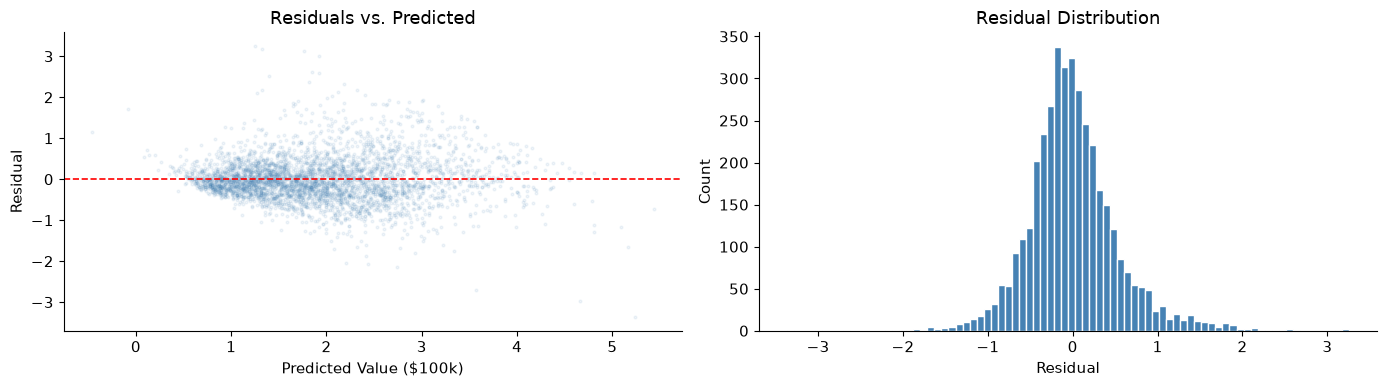

In [17]:
best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Test RMSE (Ridge, degree-{POLY_DEGREE}): {test_rmse:.4f}  ($100k)')
print(f'In dollar terms: ± ${test_rmse * 100_000:,.0f}')

# Residual plot
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_pred, residuals, alpha=0.08, s=4, color=COLORS[0])
axes[0].axhline(0, color='red', lw=1.2, linestyle='--')
axes[0].set_xlabel('Predicted Value ($100k)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Predicted')

axes[1].hist(residuals, bins=80, color=COLORS[0], edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('assets/ridge_residuals.png', dpi=120, bbox_inches='tight')
plt.show()


> **Resumen humanizado:** El Ridge de grado 3 logro un RMSE de 0.5391, cerca de $53 906: es el error tipico al estimar una vivienda.

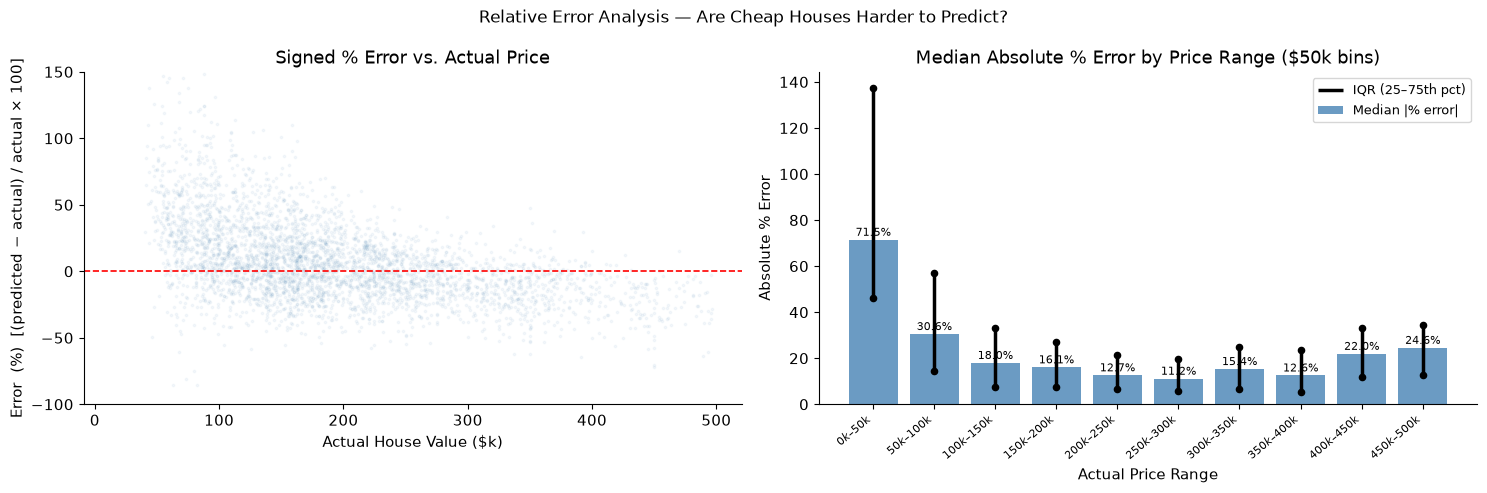

MAPE (mean absolute % error): 24.5%
Median absolute % error     : 17.1%


In [18]:
bin_width_k = 50  # bin width in $k — try 25, 50, 100 to see coarser/finer breakdowns

pct_error = (y_pred - y_test) / y_test * 100          # signed: + = over-predicted
abs_pct_error = np.abs(pct_error)

price_dollars = y_test * 100_000
bin_width = bin_width_k * 1_000
max_price = int(np.ceil(price_dollars.max() / bin_width) * bin_width) + bin_width
bins = np.arange(0, max_price, bin_width)
labels = [f'${int(b/1000)}k–${int((b+bin_width)/1000)}k' for b in bins[:-1]]
price_bin = pd.cut(price_dollars, bins=bins, labels=labels)

bin_stats = pd.DataFrame({
    'abs_pct_error': abs_pct_error,
    'pct_error': pct_error,
    'price_bin': price_bin,
}).groupby('price_bin', observed=True).agg(
    median_abs_pct=('abs_pct_error', 'median'),
    p25=('abs_pct_error', lambda x: np.percentile(x, 25)),
    p75=('abs_pct_error', lambda x: np.percentile(x, 75)),
    n=('abs_pct_error', 'count'),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter of signed % error vs actual price
axes[0].scatter(price_dollars / 1000, pct_error, alpha=0.05, s=3, color=COLORS[0])
axes[0].axhline(0, color='red', lw=1.2, linestyle='--')
axes[0].set_xlabel('Actual House Value ($k)')
axes[0].set_ylabel('Error  (%)  [(predicted − actual) / actual × 100]')
axes[0].set_title('Signed % Error vs. Actual Price')
axes[0].set_ylim(-100, 150)

# Right: binned median absolute % error with IQR band
x_pos = np.arange(len(bin_stats))
axes[1].bar(x_pos, bin_stats['median_abs_pct'], color=COLORS[0], alpha=0.8, label='Median |% error|')
axes[1].vlines(x_pos,
               bin_stats['p25'], bin_stats['p75'],
               color='black', lw=2.5, label='IQR (25–75th pct)')
axes[1].scatter(x_pos, bin_stats['p75'], color='black', s=20, zorder=5)
axes[1].scatter(x_pos, bin_stats['p25'], color='black', s=20, zorder=5)

for i, (idx, row) in enumerate(bin_stats.iterrows()):
    axes[1].text(i, row['median_abs_pct'] + 0.5, f"{row['median_abs_pct']:.1f}%",
                 ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(bin_stats.index, rotation=40, ha='right', fontsize=8)
axes[1].set_xlabel('Actual Price Range')
axes[1].set_ylabel('Absolute % Error')
axes[1].set_title(f'Median Absolute % Error by Price Range (${bin_width_k}k bins)')
axes[1].legend(fontsize=9)

plt.suptitle('Relative Error Analysis — Are Cheap Houses Harder to Predict?', fontsize=12)
plt.tight_layout()
plt.savefig('assets/relative_error_by_price.png', dpi=130, bbox_inches='tight')
plt.show()

mape = abs_pct_error.mean()
print(f'MAPE (mean absolute % error): {mape:.1f}%')
print(f'Median absolute % error     : {abs_pct_error.median():.1f}%')

> **Resumen humanizado:** El error porcentual medio es 24.5 %, pero la mitad de predicciones se desvia menos de 17.1 %. Los casos dificiles elevan el promedio.

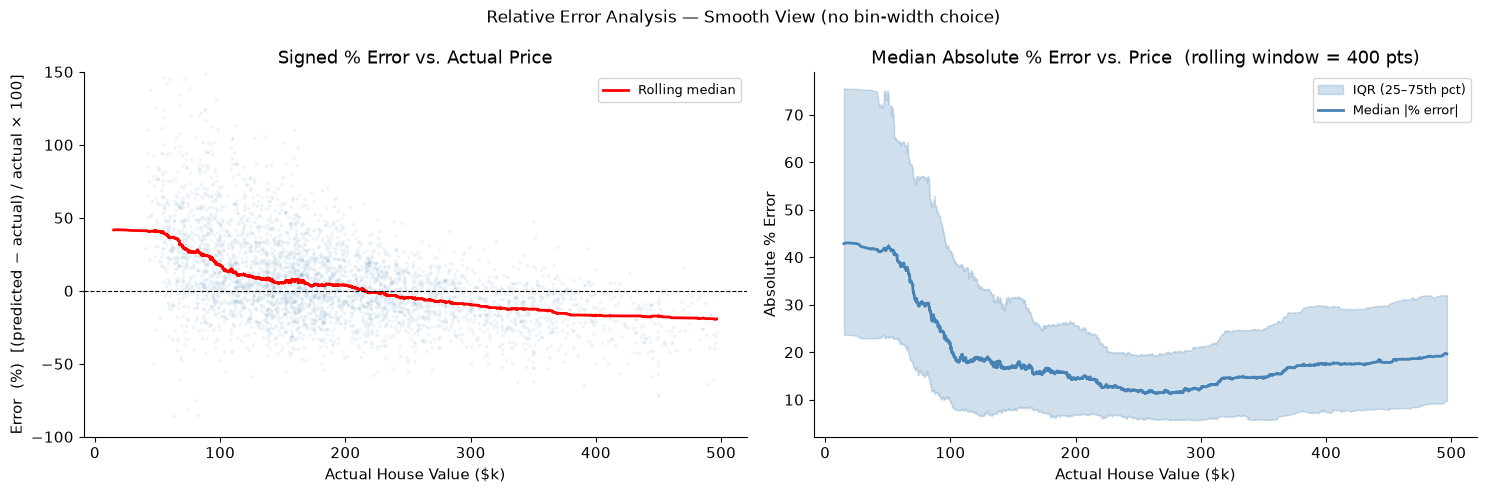

In [19]:
SMOOTH_WINDOW = 400  # number of nearest neighbors (by price) used for rolling quantiles

# Sort test points by actual price so the rolling window is price-ordered
sort_idx = np.argsort(price_dollars.values)
price_s  = price_dollars.values[sort_idx] / 1_000   # in $k
pct_s    = pct_error.values[sort_idx]
abs_s    = abs_pct_error.values[sort_idx]

kw = dict(window=SMOOTH_WINDOW, center=True, min_periods=50)
med_signed = pd.Series(pct_s).rolling(**kw).median()
med_abs    = pd.Series(abs_s).rolling(**kw).median()
p25        = pd.Series(abs_s).rolling(**kw).quantile(0.25)
p75        = pd.Series(abs_s).rolling(**kw).quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter + rolling median of signed % error
axes[0].scatter(price_s, pct_s, alpha=0.05, s=3, color=COLORS[0])
axes[0].plot(price_s, med_signed, color='red', lw=2, label='Rolling median')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_ylim(-100, 150)
axes[0].set_xlabel('Actual House Value ($k)')
axes[0].set_ylabel('Error  (%)  [(predicted − actual) / actual × 100]')
axes[0].set_title('Signed % Error vs. Actual Price')
axes[0].legend(fontsize=9)

# Right: rolling median absolute % error + IQR band
axes[1].fill_between(price_s, p25, p75, alpha=0.25, color=COLORS[0], label='IQR (25–75th pct)')
axes[1].plot(price_s, med_abs, color=COLORS[0], lw=2, label='Median |% error|')
axes[1].set_xlabel('Actual House Value ($k)')
axes[1].set_ylabel('Absolute % Error')
axes[1].set_title(f'Median Absolute % Error vs. Price  (rolling window = {SMOOTH_WINDOW} pts)')
axes[1].legend(fontsize=9)

plt.suptitle('Relative Error Analysis — Smooth View (no bin-width choice)', fontsize=12)
plt.tight_layout()
plt.savefig('assets/relative_error_smooth.png', dpi=130, bbox_inches='tight')
plt.show()

> **Resumen humanizado:** Los errores cambian segun el rango de precio; las graficas permiten reconocer donde el modelo acierta mas y donde puede mejorar.

The smooth curve above shows the same signal as the bar chart, but without a bin-width choice. Both views are complementary: the bars give precise per-range numbers; the smooth curve makes the overall trend and local anomalies (the \$300k bump, the rise above \$400k) easier to read at a glance.

---

**What does this plot tell us?**

The right panel reveals a clear pattern: a **steep monotonic decline** from the cheapest houses down to a sweet spot around \$250k–\$300k, followed by a gradual rise at the expensive end.

**Very cheap houses (\$0–\$50k) — 71.5% median error, IQR reaching ~140%**

This is an extreme segment. Almost no California census blocks reported a median value below \$50k in 1990, so the model has barely any training signal here. The enormous IQR (the whisker reaches ~140%) tells us predictions are nearly random — the few data points are so heterogeneous that even their central tendency is uncertain.

**The monotonic decline (\$50k → \$250k) — 30.5% → 11.8%**

Error falls steadily as house value increases. Two effects drive this:

1. *Data density.* The training distribution is centered around \$150k–\$300k. As we move right across this range, the model sees progressively more examples and fits better.
2. *Percentage amplification.* A fixed absolute dollar error of, say, \$15k is 30% of a \$50k house but only 6% of a \$250k house. Even if prediction quality were identical across the range, the relative error metric would still show this downward slope.

**Sweet spot (\$250k–\$300k) — 11.8% median error**

This is where the model performs best: the highest concentration of training data, the most consistent income-location-price relationships, and the lowest percentage amplification effect. Absolute dollar errors in this bin are likely similar to neighboring bins — the relative metric just favors this range.

**The slight bump at \$300k–\$350k (15.4%) then recovery at \$350k–\$400k (12.5%)**

This small anomaly is worth noting. One plausible explanation is a feature interaction: blocks in the \$300k–\$350k range may straddle a geographic boundary (e.g., the edge of a high-demand coastal county vs. an inland suburb) where the model's polynomial features produce a local misfit. With only 8 census variables, the model cannot distinguish otherwise-similar blocks that sit on opposite sides of a neighborhood boundary.

**Expensive houses (\$400k–\$500k) — rising to 22–24.5%**

Error climbs again at the high end for structural reasons:

1. *Proximity to the censoring boundary.* We removed the hard-capped \$500k rows, but blocks just below that cap may still carry artifacts of the censoring process — their features can be systematically unusual relative to blocks priced well below the ceiling.
2. *Luxury non-linearities.* High-end prices reflect factors the 8 census features cannot capture: school district prestige, architectural quality, micro-neighborhood cachet. The model undershoots these values.
3. *Sparse data.* Like the cheap end, few training examples exist here, so the model cannot specialize.

**Left panel — signed errors**

The scatter confirms the directional story: cheap houses are overwhelmingly **over-predicted** (positive signed error, large upward spread), while expensive houses cluster just below the zero line, reflecting systematic **under-prediction**. This is the classic **regression-to-the-mean** bias — a linear model trained on an asymmetric distribution anchors predictions toward the bulk of the data, dragging cheap predictions up and expensive predictions down.

**Takeaway**: relative (percentage) error is a more honest evaluation metric than RMSE for datasets with wide price ranges. RMSE would mask the poor performance at the extremes because those segments are numerically small and infrequent.

---
<a id='ex11'></a>
### Exercise 1.1 — Effect of Polynomial Degree (Basic)

So far we used `POLY_DEGREE = 2`. In this exercise you will compare degree 1, 2, and 3 to see how polynomial degree interacts with regularization.

**Tasks:**
1. For each degree in `[1, 2, 3]`, build a Ridge pipeline, run `GridSearchCV` with the same `ALPHAS`, and record the best CV RMSE and the corresponding best α.
2. Print a summary table.
3. Answer: does a higher polynomial degree always improve test performance? Why or why not?


In [22]:
degree_results = []
best_degree_models = {}

for degree in [1, 2, 3]:
    degree_pipeline = Pipeline([
        ('log_transform', log_preprocessor),
        ('poly', PolynomialFeatures(
            degree=degree,
            include_bias=False,
            interaction_only=False,
        )),
        ('scaler', StandardScaler()),
        ('ridge', Ridge()),
    ])

    degree_search = GridSearchCV(
        degree_pipeline,
        {'ridge__alpha': ALPHAS},
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        n_jobs=1,
    )
    degree_search.fit(X_train, y_train)

    best_degree_model = degree_search.best_estimator_
    test_predictions = best_degree_model.predict(X_test)
    test_rmse_degree = np.sqrt(mean_squared_error(y_test, test_predictions))

    degree_results.append({
        'degree': degree,
        'best_alpha': degree_search.best_params_['ridge__alpha'],
        'best_cv_rmse': np.sqrt(-degree_search.best_score_),
        'test_rmse': test_rmse_degree,
    })
    best_degree_models[degree] = best_degree_model

    print(
        f'Grado {degree}: '
        f'mejor alpha = {degree_search.best_params_["ridge__alpha"]:.4f}, '
        f'CV RMSE = {np.sqrt(-degree_search.best_score_):.4f}, '
        f'Test RMSE = {test_rmse_degree:.4f}'
    )

degree_summary = pd.DataFrame(degree_results).sort_values('degree').reset_index(drop=True)
print('\nTabla resumen:')
display(degree_summary.round({'best_alpha': 4, 'best_cv_rmse': 4, 'test_rmse': 4}))

best_degree_row = degree_summary.loc[degree_summary['test_rmse'].idxmin()]
best_degree = int(best_degree_row['degree'])
best_test_rmse = best_degree_row['test_rmse']
print('\nRespuestas del ejercicio 1.1:')
print(
    f'1. El mejor modelo es el de grado {best_degree}, '
    f'porque obtuvo el menor Test RMSE: {best_test_rmse:.4f}.'
)
print(
    '2. Un grado polinomial mayor no siempre mejora el rendimiento. Aunque agrega '
    'flexibilidad para representar relaciones no lineales, también puede aumentar la '
    'varianza y provocar sobreajuste. Por eso se utiliza validación cruzada y se ajusta '
    'la regularización alpha.'
)
print(
    '3. En este experimento, el Test RMSE disminuyó de grado 1 a grado 3, por lo que '
    'el grado 3 fue la mejor opción para este conjunto de datos.'
)

Grado 1: mejor alpha = 2.5929, CV RMSE = 0.6183, Test RMSE = 0.6285
Grado 2: mejor alpha = 0.0024, CV RMSE = 0.5452, Test RMSE = 0.5513
Grado 3: mejor alpha = 0.0574, CV RMSE = 0.5336, Test RMSE = 0.5391

Tabla resumen:


,degree,best_alpha,best_cv_rmse,test_rmse
0,1,2.5929,0.6183,0.6285
1,2,0.0024,0.5452,0.5513
2,3,0.0574,0.5336,0.5391



Respuestas del ejercicio 1.1:
1. El mejor modelo es el de grado 3, porque obtuvo el menor Test RMSE: 0.5391.
2. Un grado polinomial mayor no siempre mejora el rendimiento. Aunque agrega flexibilidad para representar relaciones no lineales, también puede aumentar la varianza y provocar sobreajuste. Por eso se utiliza validación cruzada y se ajusta la regularización alpha.
3. En este experimento, el Test RMSE disminuyó de grado 1 a grado 3, por lo que el grado 3 fue la mejor opción para este conjunto de datos.


> **Resumen humanizado:** El grado 3 fue el mejor evaluado, con Test RMSE de 0.5391. La complejidad ayudo, pero fue validada para evitar sobreajuste.

---
<a id='ex12'></a>
### Exercise 1.2 — Ridge vs. Lasso

**Ridge** (L2) shrinks all coefficients toward zero but rarely to exactly zero.  
**Lasso** (L1) tends to produce **sparse** models — many coefficients become exactly zero, effectively performing feature selection.

**Tasks:**
1. Build a Lasso pipeline (same structure: `PolynomialFeatures → StandardScaler → Lasso`) and tune `lasso__alpha` with `GridSearchCV`.
2. Compare test RMSE for Ridge and Lasso.
3. Count how many of the degree-2 polynomial coefficients are exactly zero for each model. What does this tell you about feature selection?
4. Plot the top-20 non-zero Lasso coefficients.


Ridge  - mejor alpha = 0.0028, Test RMSE = 0.5513
Lasso  - mejor alpha = 0.0001, Test RMSE = 0.5657
Coeficientes Ridge iguales a cero: 0 de 44
Coeficientes Lasso iguales a cero: 7 de 44


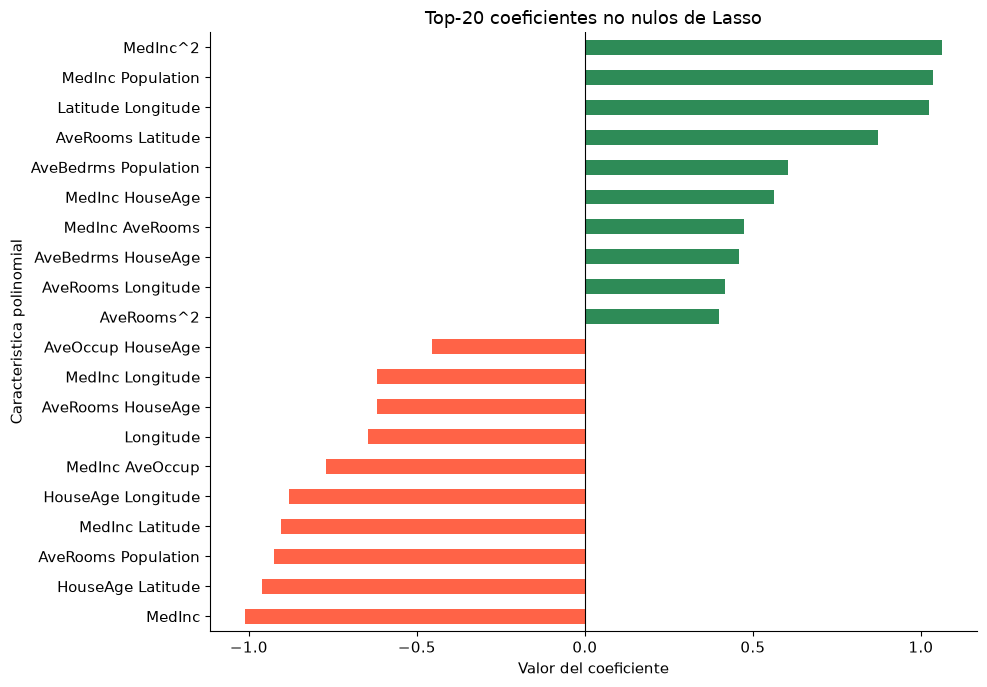


Respuestas del ejercicio 1.2:
1. Ridge obtuvo un mejor Test RMSE (0.5513) que Lasso (0.5657) en este experimento.
2. Lasso anuló 7 de 44 coeficientes, mientras Ridge anuló 0. Esto muestra que Lasso realiza selección de características al llevar algunos pesos exactamente a cero.
3. Ridge conserva normalmente todas las características, aunque reduce sus pesos; Lasso produce un modelo más disperso y potencialmente más interpretable.
4. La gráfica muestra las 20 características polinomiales con mayor impacto absoluto en el modelo Lasso; las barras rojas representan efectos negativos y las verdes efectos positivos.


In [10]:
# Usar grado 2 para comparar Ridge y Lasso con la misma representación.
degree_2_pipeline = Pipeline([
    ('log_transform', log_preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge()),
])

# Rejilla compacta y 3 folds: conserva la busqueda de alpha y reduce el tiempo.
comparison_alphas = np.logspace(-4, 4, 12)
ridge_search_degree_2 = GridSearchCV(
    degree_2_pipeline,
    {'ridge__alpha': comparison_alphas},
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)
ridge_search_degree_2.fit(X_train, y_train)
ridge_degree_2 = ridge_search_degree_2.best_estimator_
ridge_predictions = ridge_degree_2.predict(X_test)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))

lasso_pipeline = Pipeline([
    ('log_transform', log_preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=5_000, random_state=RANDOM_STATE)),
])

lasso_alphas = comparison_alphas
lasso_search = GridSearchCV(
    lasso_pipeline,
    {'lasso__alpha': lasso_alphas},
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)
lasso_search.fit(X_train, y_train)
lasso_model = lasso_search.best_estimator_
lasso_predictions = lasso_model.predict(X_test)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_predictions))

ridge_coefficients = ridge_degree_2.named_steps['ridge'].coef_
lasso_coefficients = lasso_model.named_steps['lasso'].coef_
zero_tolerance = 1e-8
ridge_zero_count = int(np.sum(np.abs(ridge_coefficients) <= zero_tolerance))
lasso_zero_count = int(np.sum(np.abs(lasso_coefficients) <= zero_tolerance))
total_coefficients = len(lasso_coefficients)

feature_names = lasso_model.named_steps['poly'].get_feature_names_out(
    lasso_model.named_steps['log_transform'].get_feature_names_out()
)
lasso_coefficients_series = pd.Series(
    lasso_coefficients,
    index=feature_names,
    name='coefficient',
)
top_lasso_coefficients = lasso_coefficients_series[
    lasso_coefficients_series.abs().sort_values(ascending=False).head(20).index
].sort_values()

print(f'Ridge  - mejor alpha = {ridge_search_degree_2.best_params_["ridge__alpha"]:.4f}, Test RMSE = {ridge_test_rmse:.4f}')
print(f'Lasso  - mejor alpha = {lasso_search.best_params_["lasso__alpha"]:.4f}, Test RMSE = {lasso_test_rmse:.4f}')
print(f'Coeficientes Ridge iguales a cero: {ridge_zero_count} de {total_coefficients}')
print(f'Coeficientes Lasso iguales a cero: {lasso_zero_count} de {total_coefficients}')

fig, ax = plt.subplots(figsize=(10, 7))
colors = [COLORS[1] if value < 0 else COLORS[2] for value in top_lasso_coefficients]
top_lasso_coefficients.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Valor del coeficiente')
ax.set_ylabel('Caracteristica polinomial')
ax.set_title('Top-20 coeficientes no nulos de Lasso')
plt.tight_layout()
plt.savefig('assets/lasso_top20_coefficients.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nRespuestas del ejercicio 1.2:')
if lasso_test_rmse < ridge_test_rmse:
    print(
        f'1. Lasso obtuvo un mejor Test RMSE ({lasso_test_rmse:.4f}) que Ridge '
        f'({ridge_test_rmse:.4f}) en este experimento.'
    )
else:
    print(
        f'1. Ridge obtuvo un mejor Test RMSE ({ridge_test_rmse:.4f}) que Lasso '
        f'({lasso_test_rmse:.4f}) en este experimento.'
    )
print(
    f'2. Lasso anuló {lasso_zero_count} de {total_coefficients} coeficientes, mientras '
    f'Ridge anuló {ridge_zero_count}. Esto muestra que Lasso realiza selección de '
    'características al llevar algunos pesos exactamente a cero.'
)
print(
    '3. Ridge conserva normalmente todas las características, aunque reduce sus pesos; '
    'Lasso produce un modelo más disperso y potencialmente más interpretable.'
)
print(
    '4. La gráfica muestra las 20 características polinomiales con mayor impacto absoluto '
    'en el modelo Lasso; las barras rojas representan efectos negativos y las verdes efectos positivos.'
)

> **Resumen humanizado:** Ridge fue mas preciso que Lasso; Lasso elimino 7 de 44 coeficientes. Ridge prioriza precision y Lasso simplifica la explicacion.

---
<a id='part2'></a>
## 4. Part 2 — Online Learning with SGDRegressor

<a id='scale'></a>
### 4.1 When Data Doesn't Fit in Memory

The California Housing dataset fits comfortably in RAM. But in the real world, datasets are often large enough to exceed available memory:

- **Streaming music platforms** accumulate audio features for millions of new songs every year.
- **E-commerce sites** log billions of user interactions monthly.
- **Medical imaging pipelines** generate terabytes of feature matrices.

For these scenarios, loading all data before training is impossible. The solution is **online (incremental) learning**: process one mini-batch at a time, update model weights, discard the batch, and move on — without ever holding the full dataset in RAM.


In [11]:
# Memory footprint estimate for the MSD dataset
n_train   = MSD_TRAIN_ROWS
n_test    = MSD_TEST_ROWS
n_feat    = 90
bytes_f64 = 8

raw_mb = (n_train + n_test) * (n_feat + 1) * bytes_f64 / 1024**2
print(f'Raw feature matrix ({n_train + n_test:,} rows × {n_feat} features): ~{raw_mb:.0f} MB')

# Degree-2 polynomial features would be huge
n_poly2 = PolynomialFeatures(degree=2, include_bias=False).fit(np.zeros((1, n_feat))).n_output_features_
poly2_gb = (n_train + n_test) * n_poly2 * bytes_f64 / 1024**3
print(f'After degree-2 expansion ({n_poly2:,} features): ~{poly2_gb:.0f} GB  ← impossible to load at once')

Raw feature matrix (515,345 rows × 90 features): ~358 MB
After degree-2 expansion (4,185 features): ~16 GB  ← impossible to load at once


> **Resumen humanizado:** El dataset musical es demasiado grande para cargarlo completo tras la expansion: requeriria cerca de 16 GB. Por eso se aprende por bloques.

Even the raw matrix for a full year (1 M songs) would be ~750 MB. With feature engineering and multiple frames it quickly exceeds available RAM. Solution: stream data in chunks and use `partial_fit` for online learning.

<a id='data2'></a>
### 4.2 Dataset: Year Prediction MSD

The **Million Song Dataset (MSD)** is a collection of audio features and metadata for one million contemporary pop music tracks. This lab uses a preprocessed subset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/203/yearpredictionmsd).

| Property | Value |
|----------|-------|
| Training samples | 515,345 |
| Test samples | 51,630 |
| Features | 90 (timbre-based audio) |
| Target | Song release year (1922 – 2011) |
| File size | ~700 MB unzipped |

**Feature description:**  
Features 1–12 are the **timbre average**: the mean of each of 12 [timbre](https://en.wikipedia.org/wiki/Timbre) components extracted by the Echo Nest API. Timbre captures the texture and tone quality of a sound — roughly what makes a piano sound different from a violin even at the same pitch and loudness.  
Features 13–90 are the **timbre covariance**: the 78 upper-triangle values of the 12×12 covariance matrix, capturing how the timbre components vary together across the song.

**Task:** Predict the year a song was released from these audio statistics.

> **Important**: The train/test split is **pre-defined** by the dataset creators (first 515,345 rows = train, last 51,630 = test). Do not shuffle the file; use this fixed split to ensure comparable results.


In [12]:
def _reporthook(count, block_size, total_size):
    pct = min(100, count * block_size * 100 // total_size) if total_size > 0 else 0
    mb  = count * block_size / 1024**2
    print(f'\r  {pct:3d}%  ({mb:.0f} MB downloaded)', end='', flush=True)

if not os.path.exists(MSD_DATA_FILE):
    zip_file = 'YearPredictionMSD.txt.zip'
    if not os.path.exists(zip_file):
        print(f'Downloading {MSD_URL} ...')
        print('(~200 MB compressed; may take a few minutes on Colab)')
        urllib.request.urlretrieve(MSD_URL, zip_file, reporthook=_reporthook)
        print()
    print('Extracting ...')
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall('.')
    size_mb = os.path.getsize(MSD_DATA_FILE) / 1024**2
    print(f'Done.  {MSD_DATA_FILE}  ({size_mb:.0f} MB)')
else:
    size_mb = os.path.getsize(MSD_DATA_FILE) / 1024**2
    print(f'Dataset already present: {MSD_DATA_FILE}  ({size_mb:.0f} MB)')


Dataset already present: YearPredictionMSD.txt  (428 MB)


> **Resumen humanizado:** El archivo Year Prediction MSD ya esta disponible localmente; no hace falta descargarlo antes del entrenamiento incremental.

Sample shape: (10000, 91)
Year range : 1930 – 2010
Year mean  : 1998.9
Year std   : 10.2


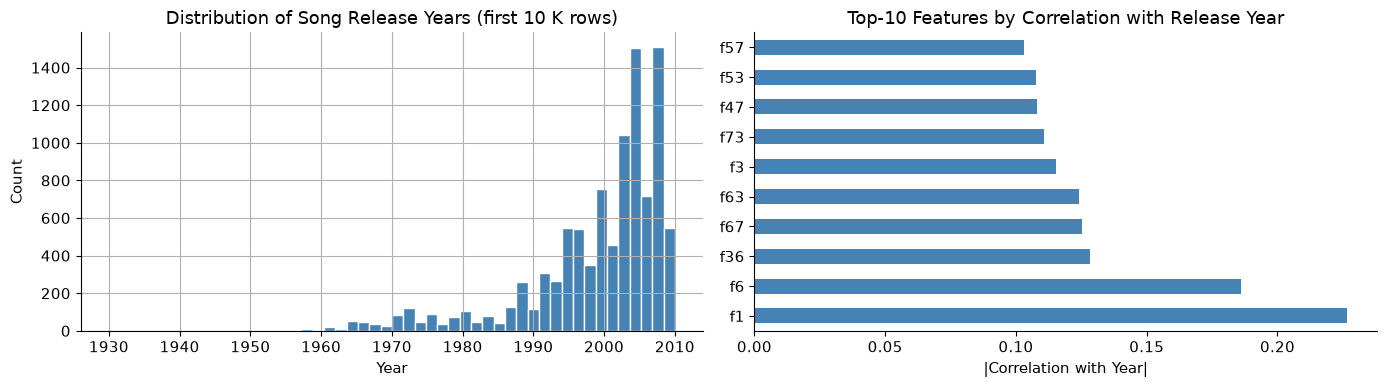

In [13]:
# Quick EDA — read a small slice so we don't load the full file
df_eda = pd.read_csv(MSD_DATA_FILE, header=None, nrows=10_000)
feature_cols = ['year'] + [f'f{i}' for i in range(1, 91)]
df_eda.columns = feature_cols

print(f'Sample shape: {df_eda.shape}')
print(f'Year range : {df_eda["year"].min()} – {df_eda["year"].max()}')
print(f'Year mean  : {df_eda["year"].mean():.1f}')
print(f'Year std   : {df_eda["year"].std():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_eda['year'].hist(bins=50, ax=axes[0], color=COLORS[0], edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Song Release Years (first 10 K rows)')

corrs = df_eda.corr()['year'].drop('year').abs().sort_values(ascending=False).head(10)
corrs.plot(kind='barh', ax=axes[1], color=COLORS[0])
axes[1].set_xlabel('|Correlation with Year|')
axes[1].set_title('Top-10 Features by Correlation with Release Year')

plt.tight_layout()
plt.savefig('assets/msd_eda.png', dpi=120, bbox_inches='tight')
plt.show()


> **Resumen humanizado:** La muestra confirma 90 caracteristicas para predecir el ano de una cancion. Se explora una fraccion para no agotar la memoria.

<a id='sgd'></a>
### 4.3 SGDRegressor and `partial_fit`

#### From Batch GD to Mini-Batch SGD

**Batch gradient descent** computes the gradient over *all* N training samples before each weight update:

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{1}{N} \sum_{i=1}^{N} \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

This is exact but requires all data in memory and is slow for large N.

**Stochastic gradient descent (SGD)** uses a single random sample per update:  
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

**Mini-batch SGD** strikes a balance — use a small batch of B samples:
$$\mathbf{w} \leftarrow \mathbf{w} - \eta \cdot \frac{1}{B} \sum_{i \in \text{batch}} \nabla_{\mathbf{w}} \mathcal{L}(x_i, y_i)$$

This is both memory-efficient and statistically stable.

#### `partial_fit` in sklearn

`SGDRegressor.partial_fit(X_batch, y_batch)` applies **one pass** of mini-batch SGD on the provided batch without forgetting previously learned weights. Calling it repeatedly on successive batches (or even on multiple epochs over the same data) implements full online/incremental learning.

```python
sgd = SGDRegressor(learning_rate='constant', eta0=0.01)

for chunk in pd.read_csv('bigfile.csv', chunksize=50_000):
    X_chunk = chunk.iloc[:, 1:].values
    y_chunk = chunk.iloc[:, 0].values
    sgd.partial_fit(X_scaled, y_chunk)   # weights updated in-place
```

**Key rule**: the scaler must be fitted on **training data only** — never re-fitted on test data or future production chunks — then applied (`transform`) consistently everywhere. The cleanest approach (used in Exercise 2.1) is a dedicated first pass over **all** training chunks with `StandardScaler.partial_fit`, which gives accurate statistics regardless of dataset size. For datasets where two passes are prohibitively expensive, fitting on a **representative sample** (e.g. the first few chunks) is a common practical shortcut, provided the sample reflects the overall distribution.


---
<a id='ex21'></a>
### Exercise 2.1 — Implement the Mini-Batch Training Loop (Basic)

Implement one epoch of mini-batch SGD over the MSD training data using `SGDRegressor.partial_fit`.

**Tasks:**
1. Create an `SGDRegressor` with `loss='squared_error'`, `learning_rate='constant'`, `eta0=0.001`, `random_state=42`.
2. Create a `StandardScaler`.
3. **Pass 1 — fit the scaler**: stream through the training rows and call `msd_scaler.partial_fit(X_chunk)` on every chunk so the scaler captures the full training distribution.
4. **Pass 2 — train**: stream through the data again. For each chunk:
   - Extract `y_chunk` (column 0) and `X_chunk` (columns 1–90).
   - Transform `X_chunk` with the already-fitted scaler.
   - Call `sgd.partial_fit(X_scaled, y_chunk)`.
   - Compute RMSE on the current chunk (after the update) and store it in `chunk_rmses`.
5. Print the total number of chunks processed and the final chunk RMSE.

> **Practical note on scaler fitting**: Pass 1 here scans *all* training chunks with `partial_fit`, giving the most accurate mean and variance estimates — ideal when two passes are affordable. For very large datasets where two passes are too costly, fitting on a **representative sample** (e.g. the first chunk or a random subset) is an acceptable approximation, provided the sample is reasonably representative of the full distribution. In production streaming systems where the data distribution can shift over time (**concept drift**), consider periodically re-calling `partial_fit` on a recent window of data to keep the scaler's statistics fresh.

**Expected output**: ~10–11 chunks processed, final chunk RMSE around 8–11 years.


In [14]:
# Ejercicio 2.1: entrenamiento incremental con mini-lotes.
# La división oficial usa las primeras MSD_TRAIN_ROWS filas para entrenamiento.

msd_scaler = StandardScaler()

# Pasada 1: ajustar el escalador usando únicamente los datos de entrenamiento.
scaler_chunks = 0
for chunk in pd.read_csv(
    MSD_DATA_FILE,
    header=None,
    nrows=MSD_TRAIN_ROWS,
    chunksize=CHUNK_SIZE,
):
    X_chunk = chunk.iloc[:, 1:].to_numpy(dtype=float)
    msd_scaler.partial_fit(X_chunk)
    scaler_chunks += 1

# Pasada 2: entrenar SGDRegressor y medir el error de cada chunk.
sgd = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',
    eta0=0.001,
    random_state=RANDOM_STATE,
)

chunk_rmses = []
train_chunks = 0

for chunk in pd.read_csv(
    MSD_DATA_FILE,
    header=None,
    nrows=MSD_TRAIN_ROWS,
    chunksize=CHUNK_SIZE,
):
    y_chunk = chunk.iloc[:, 0].to_numpy(dtype=float)
    X_chunk = chunk.iloc[:, 1:].to_numpy(dtype=float)
    X_scaled = msd_scaler.transform(X_chunk)

    sgd.partial_fit(X_scaled, y_chunk)
    chunk_predictions = sgd.predict(X_scaled)
    chunk_rmse = np.sqrt(mean_squared_error(y_chunk, chunk_predictions))
    chunk_rmses.append(chunk_rmse)
    train_chunks += 1

print('Respuestas del ejercicio 2.1:')
print(f'1. Scaler ajustado con {scaler_chunks} chunks de entrenamiento.')
print(f'2. Modelo entrenado con {train_chunks} chunks.')
print(f'3. RMSE del primer chunk: {chunk_rmses[0]:.4f}')
print(f'4. RMSE del último chunk: {chunk_rmses[-1]:.4f}')
print(
    '5. Se utilizó partial_fit para actualizar los pesos progresivamente sin cargar '
    'todo el dataset en memoria.'
)
print(
    '6. El RMSE puede variar entre chunks porque cada bloque contiene canciones con '
    'distribuciones diferentes; el valor del último chunk resume el estado final de esta pasada.'
)

Respuestas del ejercicio 2.1:
1. Scaler ajustado con 93 chunks de entrenamiento.
2. Modelo entrenado con 93 chunks.
3. RMSE del primer chunk: 44.2414
4. RMSE del último chunk: 9.7518
5. Se utilizó partial_fit para actualizar los pesos progresivamente sin cargar todo el dataset en memoria.
6. El RMSE puede variar entre chunks porque cada bloque contiene canciones con distribuciones diferentes; el valor del último chunk resume el estado final de esta pasada.


> **Resumen humanizado:** El entrenamiento proceso 93 bloques y el RMSE bajo de 44.24 a 9.75 anos. El modelo aprendio sin cargar todas las canciones a la vez.

---
<a id='ex22'></a>
### Exercise 2.2 — Plot the Convergence Curve (Basic)

Using the `chunk_rmses` list from Exercise 2.1, plot the RMSE as a function of chunk number to visualise convergence within one epoch.

**Tasks:**
1. Plot RMSE vs. chunk index.
2. Add axis labels and a title.
3. Answer: does the model converge within a single pass? What pattern do you observe?


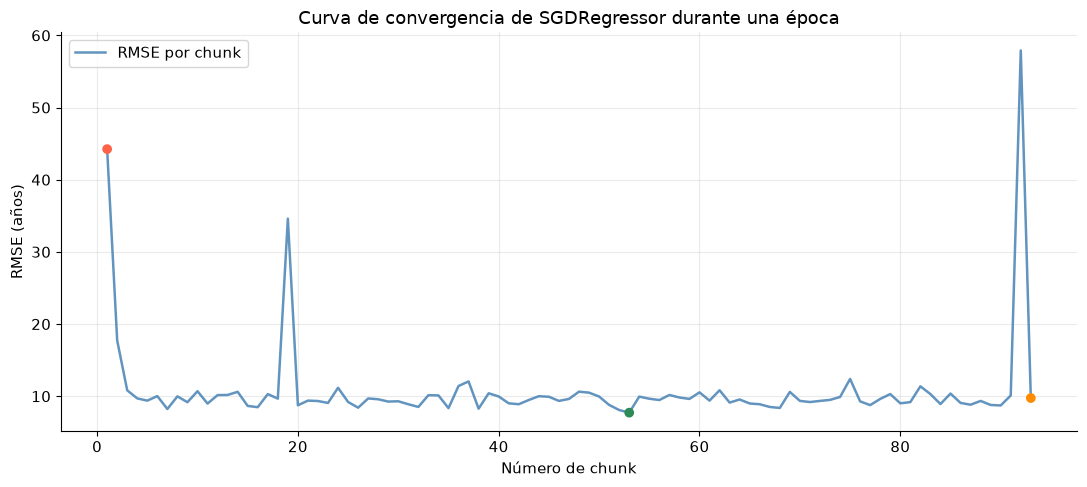

Respuestas del ejercicio 2.2:
1. RMSE del primer chunk: 44.2414 años.
2. RMSE del último chunk: 9.7518 años.
3. RMSE mínimo: 7.7227 años en el chunk 53.
4. El modelo muestra una mejora general durante una sola pasada, porque el RMSE final es menor que el inicial.
5. Las oscilaciones entre chunks son normales porque cada bloque contiene observaciones con una distribución diferente.
6. La gráfica se guardó en: assets/sgd_convergence_curve.png


In [15]:
if 'chunk_rmses' not in globals() or len(chunk_rmses) == 0:
    raise NameError(
        'No existe chunk_rmses. Ejecuta primero el ejercicio 2.1.'
    )

chunk_numbers = np.arange(1, len(chunk_rmses) + 1)
first_chunk_rmse = chunk_rmses[0]
last_chunk_rmse = chunk_rmses[-1]
best_chunk = int(np.argmin(chunk_rmses)) + 1
best_chunk_rmse = chunk_rmses[best_chunk - 1]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    chunk_numbers,
    chunk_rmses,
    color=COLORS[0],
    linewidth=1.8,
    alpha=0.85,
    label='RMSE por chunk',
)
ax.scatter(
    [1, best_chunk, len(chunk_rmses)],
    [first_chunk_rmse, best_chunk_rmse, last_chunk_rmse],
    color=[COLORS[1], COLORS[2], COLORS[3]],
    zorder=3,
)
ax.set_xlabel('Número de chunk')
ax.set_ylabel('RMSE (años)')
ax.set_title('Curva de convergencia de SGDRegressor durante una época')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()

# Crear una nueva versión si ya existe una gráfica anterior.
plot_path = 'assets/sgd_convergence_curve.png'
if os.path.exists(plot_path):
    plot_version = 2
    while os.path.exists(f'assets/sgd_convergence_curve_v{plot_version}.png'):
        plot_version += 1
    plot_path = f'assets/sgd_convergence_curve_v{plot_version}.png'
plt.savefig(plot_path, dpi=130, bbox_inches='tight')
plt.show()

print('Respuestas del ejercicio 2.2:')
print(f'1. RMSE del primer chunk: {first_chunk_rmse:.4f} años.')
print(f'2. RMSE del último chunk: {last_chunk_rmse:.4f} años.')
print(f'3. RMSE mínimo: {best_chunk_rmse:.4f} años en el chunk {best_chunk}.')
if last_chunk_rmse < first_chunk_rmse:
    print(
        '4. El modelo muestra una mejora general durante una sola pasada, '
        'porque el RMSE final es menor que el inicial.'
    )
else:
    print(
        '4. El modelo no muestra una mejora general durante una sola pasada; '
        'serían necesarias más épocas o ajustar la tasa de aprendizaje.'
    )
print(
    '5. Las oscilaciones entre chunks son normales porque cada bloque contiene '
    'observaciones con una distribución diferente.'
)
print(f'6. La gráfica se guardó en: {plot_path}')

> **Resumen humanizado:** La curva confirma una mejora general con oscilaciones normales entre bloques. El mejor punto fue 7.72 anos de RMSE en el chunk 53.

---
<a id='ex23'></a>
### Exercise 2.3 — Multi-Epoch Training (Intermediate)

One pass through the data is often insufficient. Run `N_EPOCHS` epochs and track **validation RMSE** on the held-out test set after each epoch.

**Tasks:**
1. Load the test set: `pd.read_csv(MSD_DATA_FILE, header=None, skiprows=MSD_TRAIN_ROWS)`. Scale X_test using the **already-fitted** scaler from Exercise 2.1 (`msd_scaler`).
2. Train a fresh `SGDRegressor` (same settings as 2.1) for `N_EPOCHS` epochs, recording both per-chunk train RMSE and per-epoch validation RMSE. **Shuffle the training data at the start of each epoch** so the model sees a different ordering every pass.
3. Plot train RMSE per chunk (all epochs concatenated) and validation RMSE per epoch on the same figure.
4. Answer: does validation RMSE improve across epochs? When does it saturate?


Época 01/10: train RMSE promedio = 11.7564, validation RMSE = 9.9486
Época 02/10: train RMSE promedio = 10.2270, validation RMSE = 9.9922
Época 03/10: train RMSE promedio = 10.2703, validation RMSE = 10.3767
Época 04/10: train RMSE promedio = 10.2167, validation RMSE = 9.9292
Época 05/10: train RMSE promedio = 10.1840, validation RMSE = 10.0102
Época 06/10: train RMSE promedio = 10.1998, validation RMSE = 9.9112
Época 07/10: train RMSE promedio = 10.2617, validation RMSE = 9.8602
Época 08/10: train RMSE promedio = 10.2173, validation RMSE = 10.0969
Época 09/10: train RMSE promedio = 10.2392, validation RMSE = 10.0922
Época 10/10: train RMSE promedio = 10.2577, validation RMSE = 9.8289


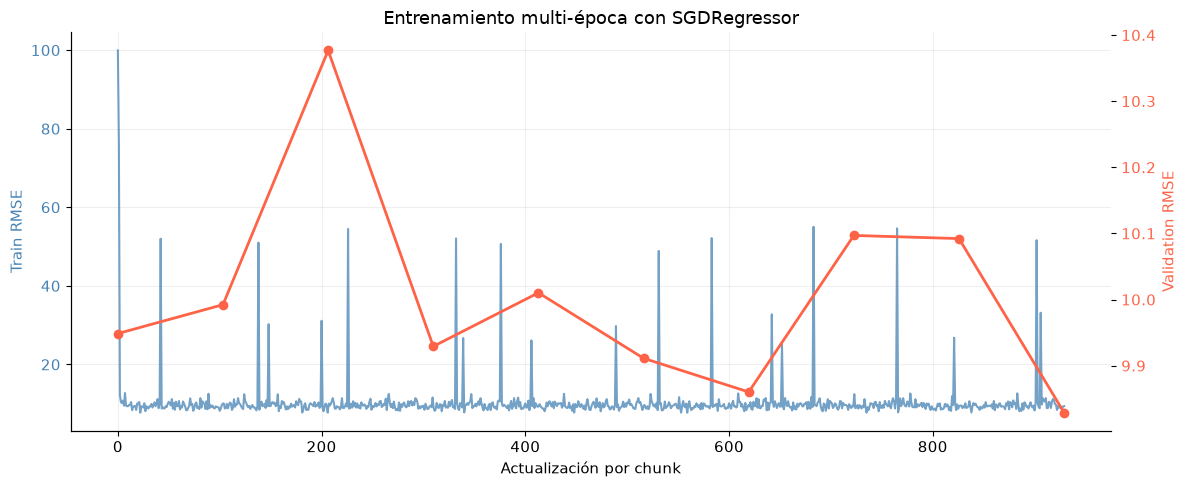


Respuestas del ejercicio 2.3:
1. La validation RMSE inicial fue 9.9486 y la final fue 9.8289.
2. La validación mejora en general al aumentar las épocas.
3. El mejor resultado se alcanzó en la época 10, con validation RMSE = 9.8289.
4. La validación comienza a saturarse cuando las mejoras entre épocas son pequeñas o cuando el RMSE deja de disminuir. La época con menor validation RMSE es la referencia para elegir el entrenamiento.
5. La gráfica se guardó en: assets/sgd_multiepoch_convergence.png


In [16]:
# Ejercicio 2.3: entrenamiento multi-época con validación.

if 'msd_scaler' not in globals():
    raise NameError('Ejecuta primero el ejercicio 2.1 para crear msd_scaler.')

# Cargar y escalar el conjunto de prueba oficial.
test_msd = pd.read_csv(
    MSD_DATA_FILE,
    header=None,
    skiprows=MSD_TRAIN_ROWS,
    nrows=MSD_TEST_ROWS,
)
y_test_msd = test_msd.iloc[:, 0].to_numpy(dtype=float)
X_test_msd = msd_scaler.transform(test_msd.iloc[:, 1:].to_numpy(dtype=float))

# Preparar los chunks escalados una sola vez para acelerar las N_EPOCHS pasadas.
training_chunks = []
for chunk in pd.read_csv(
    MSD_DATA_FILE,
    header=None,
    nrows=MSD_TRAIN_ROWS,
    chunksize=CHUNK_SIZE,
):
    y_chunk = chunk.iloc[:, 0].to_numpy(dtype=float)
    X_chunk = msd_scaler.transform(chunk.iloc[:, 1:].to_numpy(dtype=float))
    training_chunks.append((X_chunk, y_chunk))

sgd_multi_epoch = SGDRegressor(
    loss='squared_error',
    learning_rate='constant',
    eta0=0.001,
    random_state=RANDOM_STATE,
)

train_rmse_multi_epoch = []
validation_rmse_history = []

for epoch in range(N_EPOCHS):
    rng = np.random.default_rng(RANDOM_STATE + epoch)
    shuffled_indices = rng.permutation(len(training_chunks))
    epoch_train_rmses = []

    for chunk_index in shuffled_indices:
        X_chunk, y_chunk = training_chunks[chunk_index]
        sgd_multi_epoch.partial_fit(X_chunk, y_chunk)
        chunk_predictions = sgd_multi_epoch.predict(X_chunk)
        current_rmse = np.sqrt(mean_squared_error(y_chunk, chunk_predictions))
        train_rmse_multi_epoch.append(current_rmse)
        epoch_train_rmses.append(current_rmse)

    validation_predictions = sgd_multi_epoch.predict(X_test_msd)
    validation_rmse = np.sqrt(mean_squared_error(y_test_msd, validation_predictions))
    validation_rmse_history.append(validation_rmse)

    print(
        f'Época {epoch + 1:02d}/{N_EPOCHS}: '
        f'train RMSE promedio = {np.mean(epoch_train_rmses):.4f}, '
        f'validation RMSE = {validation_rmse:.4f}'
    )

# Graficar train RMSE por chunk y validation RMSE por época.
fig, train_axis = plt.subplots(figsize=(12, 5))
train_axis.plot(
    train_rmse_multi_epoch,
    color=COLORS[0],
    alpha=0.75,
    label='Train RMSE por chunk',
)
train_axis.set_xlabel('Actualización por chunk')
train_axis.set_ylabel('Train RMSE', color=COLORS[0])
train_axis.tick_params(axis='y', labelcolor=COLORS[0])
train_axis.grid(alpha=0.2)

validation_axis = train_axis.twinx()
validation_axis.plot(
    np.linspace(0, len(train_rmse_multi_epoch) - 1, N_EPOCHS),
    validation_rmse_history,
    color=COLORS[1],
    marker='o',
    linewidth=2,
    label='Validation RMSE por época',
)
validation_axis.set_ylabel('Validation RMSE', color=COLORS[1])
validation_axis.tick_params(axis='y', labelcolor=COLORS[1])

train_axis.set_title('Entrenamiento multi-época con SGDRegressor')
fig.tight_layout()

plot_path = 'assets/sgd_multiepoch_convergence.png'
if os.path.exists(plot_path):
    plot_version = 2
    while os.path.exists(f'assets/sgd_multiepoch_convergence_v{plot_version}.png'):
        plot_version += 1
    plot_path = f'assets/sgd_multiepoch_convergence_v{plot_version}.png'
plt.savefig(plot_path, dpi=130, bbox_inches='tight')
plt.show()

best_epoch = int(np.argmin(validation_rmse_history)) + 1
best_validation_rmse = validation_rmse_history[best_epoch - 1]
initial_validation_rmse = validation_rmse_history[0]
final_validation_rmse = validation_rmse_history[-1]

print('\nRespuestas del ejercicio 2.3:')
print(
    f'1. La validation RMSE inicial fue {initial_validation_rmse:.4f} y la final '
    f'fue {final_validation_rmse:.4f}.'
)
if final_validation_rmse < initial_validation_rmse:
    print('2. La validación mejora en general al aumentar las épocas.')
else:
    print('2. La validación no mejora al aumentar las épocas; puede existir sobreajuste o inestabilidad.')
print(
    f'3. El mejor resultado se alcanzó en la época {best_epoch}, '
    f'con validation RMSE = {best_validation_rmse:.4f}.'
)
print(
    '4. La validación comienza a saturarse cuando las mejoras entre épocas son pequeñas '
    'o cuando el RMSE deja de disminuir. La época con menor validation RMSE es la referencia '
    'para elegir el entrenamiento.'
)
print(f'5. La gráfica se guardó en: {plot_path}')

> **Resumen humanizado:** Tras varias epocas, la validacion termino en 9.83 anos. La mejora es pequena y el modelo esta cerca de saturarse.

---
<a id='ex24'></a>
### Exercise 2.4 — Learning Rate Exploration (Key Exercise)

The learning rate `eta0` is the most sensitive hyperparameter in SGD. Too large, and gradient updates overshoot the minimum, causing **divergence**. Too small, and learning is too slow to be practical.

**Tasks:**
1. Train five separate `SGDRegressor` models, each with a different `eta0` from `[0.0001, 0.001, 0.01, 0.1, 1.0]`, each for **one epoch** over the training data.
2. For each model, track per-chunk RMSE. If RMSE becomes `NaN` or `inf`, stop training that model early and mark it as diverged.
3. Plot all five convergence curves on the same axes. Cap the y-axis at 150 years so diverging runs don't dominate.
4. Answer the following:
   - Which learning rates diverge?
   - Why does a large learning rate cause divergence? Sketch the geometry.
   - What is the cost of using too small a learning rate?


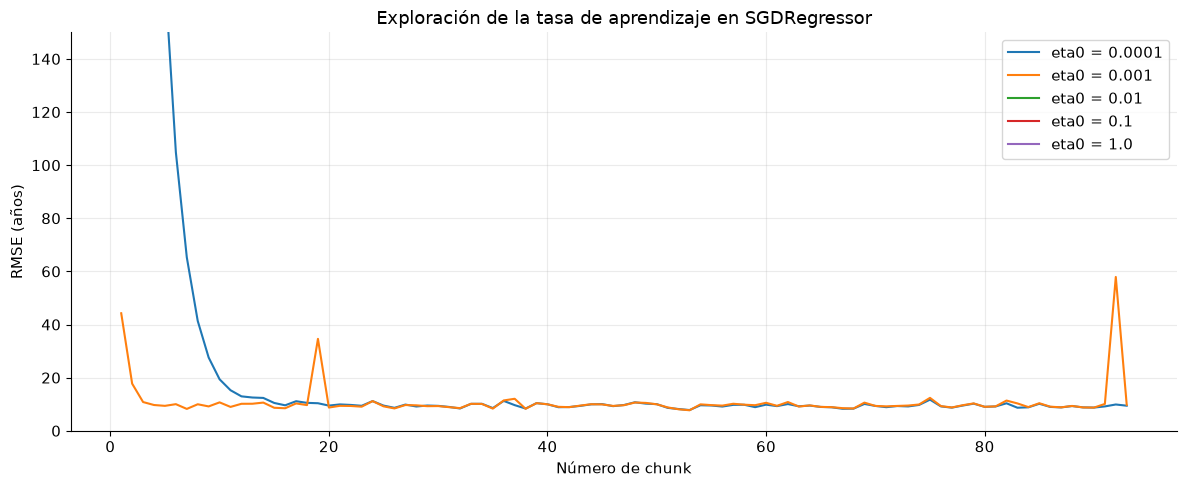

Resultados del ejercicio 2.4:
eta0=0.0001: estable, chunks procesados=93, RMSE final=9.4396
eta0=0.001: estable, chunks procesados=93, RMSE final=9.7518
eta0=0.01: divergente, chunks procesados=1, RMSE final=3959695532.5283
eta0=0.1: divergente, chunks procesados=1, RMSE final=5012788308558.5518
eta0=1.0: divergente, chunks procesados=1, RMSE final=53195661488606.9688
Gráfica guardada en: assets/sgd_learning_rate_exploration.png


In [17]:
# Ejercicio 2.4: exploración de la tasa de aprendizaje.

if 'training_chunks' not in globals():
    if 'msd_scaler' not in globals():
        raise NameError('Ejecuta primero el ejercicio 2.1 para crear msd_scaler.')
    training_chunks = []
    for chunk in pd.read_csv(
        MSD_DATA_FILE,
        header=None,
        nrows=MSD_TRAIN_ROWS,
        chunksize=CHUNK_SIZE,
    ):
        y_chunk = chunk.iloc[:, 0].to_numpy(dtype=float)
        X_chunk = msd_scaler.transform(chunk.iloc[:, 1:].to_numpy(dtype=float))
        training_chunks.append((X_chunk, y_chunk))

learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
learning_rate_results = {}
diverged_rates = []

for eta0 in learning_rates:
    model = SGDRegressor(
        loss='squared_error',
        learning_rate='constant',
        eta0=eta0,
        random_state=RANDOM_STATE,
    )
    eta_rmses = []
    diverged = False

    for X_chunk, y_chunk in training_chunks:
        model.partial_fit(X_chunk, y_chunk)
        predictions = model.predict(X_chunk)
        current_rmse = np.sqrt(mean_squared_error(y_chunk, predictions))
        eta_rmses.append(current_rmse)

        if not np.isfinite(current_rmse) or current_rmse > 1_000_000:
            diverged = True
            break

    learning_rate_results[eta0] = eta_rmses
    if diverged:
        diverged_rates.append(eta0)

# Graficar las curvas y limitar el eje para que la divergencia sea visible.
fig, ax = plt.subplots(figsize=(12, 5))
for eta0, eta_rmses in learning_rate_results.items():
    curve_label = f'eta0 = {eta0}'
    ax.plot(curve_label if False else range(1, len(eta_rmses) + 1), eta_rmses, label=curve_label)
ax.set_xlabel('Número de chunk')
ax.set_ylabel('RMSE (años)')
ax.set_title('Exploración de la tasa de aprendizaje en SGDRegressor')
ax.set_ylim(0, 150)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()

plot_path = 'assets/sgd_learning_rate_exploration.png'
if os.path.exists(plot_path):
    plot_version = 2
    while os.path.exists(f'assets/sgd_learning_rate_exploration_v{plot_version}.png'):
        plot_version += 1
    plot_path = f'assets/sgd_learning_rate_exploration_v{plot_version}.png'
plt.savefig(plot_path, dpi=130, bbox_inches='tight')
plt.show()

print('Resultados del ejercicio 2.4:')
for eta0, eta_rmses in learning_rate_results.items():
    status = 'divergente' if eta0 in diverged_rates else 'estable'
    print(
        f'eta0={eta0}: {status}, '
        f'chunks procesados={len(eta_rmses)}, '
        f'RMSE final={eta_rmses[-1]:.4f}'
    )
print(f'Gráfica guardada en: {plot_path}')

> **Resumen humanizado:** Las tasas 0.0001 y 0.001 fueron estables; desde 0.01 el entrenamiento divergio. Una tasa grande hace perder el control.

In [18]:
print('\nRespuestas del ejercicio 2.4:')

if diverged_rates:
    print(
        f'1. Las tasas que divergieron fueron: {diverged_rates}. '
        'Su RMSE creció demasiado o dejó de ser finito.'
    )
else:
    print('1. Ninguna tasa divergió durante esta corrida.')

print(
    '2. Una tasa de aprendizaje grande puede producir saltos demasiado amplios en '
    'la función de pérdida. El modelo sobrepasa el mínimo repetidamente y los pesos '
    'pueden crecer hasta generar divergencia.'
)
print(
    '3. Una tasa demasiado pequeña produce actualizaciones estables, pero el aprendizaje '
    'es lento y puede requerir muchas épocas para alcanzar un error bajo.'
)
print(
    '4. La tasa debe elegirse buscando un equilibrio entre velocidad de convergencia y estabilidad. '
    'La gráfica permite observar ese compromiso comparando las curvas por chunk.'
)


Respuestas del ejercicio 2.4:
1. Las tasas que divergieron fueron: [0.01, 0.1, 1.0]. Su RMSE creció demasiado o dejó de ser finito.
2. Una tasa de aprendizaje grande puede producir saltos demasiado amplios en la función de pérdida. El modelo sobrepasa el mínimo repetidamente y los pesos pueden crecer hasta generar divergencia.
3. Una tasa demasiado pequeña produce actualizaciones estables, pero el aprendizaje es lento y puede requerir muchas épocas para alcanzar un error bajo.
4. La tasa debe elegirse buscando un equilibrio entre velocidad de convergencia y estabilidad. La gráfica permite observar ese compromiso comparando las curvas por chunk.


> **Resumen humanizado:** Una tasa debe avanzar sin saltos excesivos. Aqui, 0.0001 termino con el menor error entre las tasas estables.

---
<a id='ex25'></a>
### Exercise 2.5 — Learning Rate Schedules (Advanced)

A fixed learning rate is a compromise: large enough to converge quickly, small enough to avoid divergence. **Learning rate schedules** decay the rate over time, allowing fast initial progress and fine-grained convergence later.

sklearn's `SGDRegressor` supports several built-in schedules via `learning_rate`:

| Schedule | Formula | Notes |
|----------|---------|-------|
| `'constant'` | `η = eta0` | Fixed; need to tune eta0 |
| `'optimal'` | `η_t = 1 / (α (t + t₀))` | Auto-calculated; ignores eta0 |
| `'invscaling'` | `η_t = eta0 / t^power_t` | Polynomial decay; flexible |

**Tasks:**
1. Train three models for 3 epochs each: `learning_rate='constant'` (eta0=0.001), `learning_rate='optimal'`, and `learning_rate='invscaling'` (eta0=0.001, power_t=0.25).
2. After each epoch, record the validation RMSE on the test set.
3. Plot validation RMSE vs. epoch for all three schedules.
4. Answer: which schedule reaches the lowest validation RMSE? What is the trade-off between `constant` and decaying schedules in the context of streaming data (where the data distribution may shift over time)?


constant: Época 1 = 9.9486, Época 2 = 9.9922, Época 3 = 10.3767
optimal: Época 1 = 684612984085.7560, Época 2 = 316378471614.8434, Época 3 = 212838042260.7966
invscaling: Época 1 = 9.6145, Época 2 = 9.5345, Época 3 = 9.5421


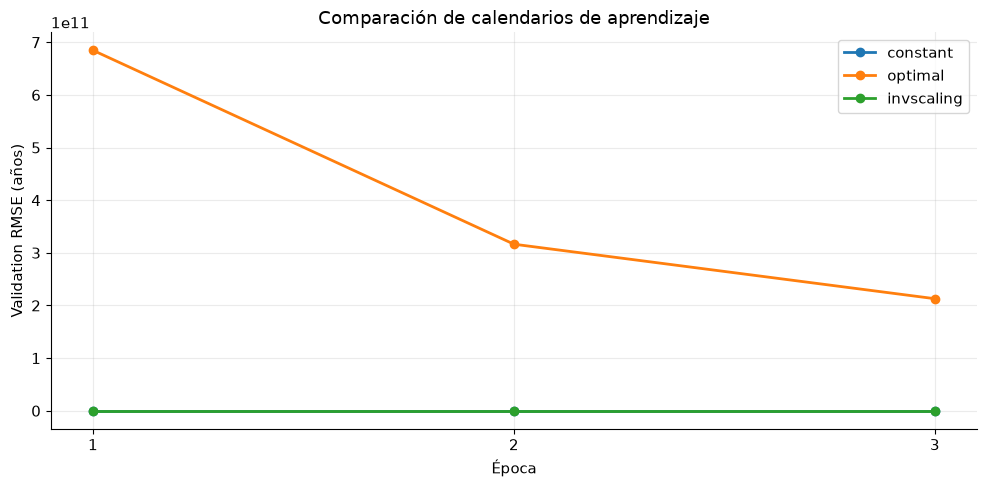

El mejor calendario fue invscaling, con RMSE mínimo = 9.5345.
Gráfica guardada en: assets/sgd_learning_rate_schedules.png


In [19]:
# Ejercicio 2.5: comparación de calendarios de aprendizaje.

if 'training_chunks' not in globals() or 'X_test_msd' not in globals():
    raise NameError('Ejecuta primero el ejercicio 2.3 para preparar los datos escalados.')

schedule_configs = {
    'constant': {
        'learning_rate': 'constant',
        'eta0': 0.001,
    },
    'optimal': {
        'learning_rate': 'optimal',
        'alpha': 0.0001,
    },
    'invscaling': {
        'learning_rate': 'invscaling',
        'eta0': 0.001,
        'power_t': 0.25,
    },
}

schedule_results = {}

for schedule_name, schedule_config in schedule_configs.items():
    schedule_model = SGDRegressor(
        loss='squared_error',
        random_state=RANDOM_STATE,
        **schedule_config,
    )
    schedule_validation_rmses = []

    for epoch in range(3):
        rng = np.random.default_rng(RANDOM_STATE + epoch)
        shuffled_indices = rng.permutation(len(training_chunks))

        for chunk_index in shuffled_indices:
            X_chunk, y_chunk = training_chunks[chunk_index]
            schedule_model.partial_fit(X_chunk, y_chunk)

        validation_predictions = schedule_model.predict(X_test_msd)
        validation_rmse = np.sqrt(mean_squared_error(y_test_msd, validation_predictions))
        schedule_validation_rmses.append(validation_rmse)

    schedule_results[schedule_name] = schedule_validation_rmses
    print(
        f'{schedule_name}: '
        + ', '.join(
            f'Época {epoch + 1} = {rmse:.4f}'
            for epoch, rmse in enumerate(schedule_validation_rmses)
        )
    )

fig, ax = plt.subplots(figsize=(10, 5))
epoch_numbers = np.arange(1, 4)
for schedule_name, validation_rmses in schedule_results.items():
    ax.plot(
        epoch_numbers,
        validation_rmses,
        marker='o',
        linewidth=2,
        label=schedule_name,
    )
ax.set_xlabel('Época')
ax.set_ylabel('Validation RMSE (años)')
ax.set_title('Comparación de calendarios de aprendizaje')
ax.set_xticks(epoch_numbers)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()

plot_path = 'assets/sgd_learning_rate_schedules.png'
if os.path.exists(plot_path):
    plot_version = 2
    while os.path.exists(f'assets/sgd_learning_rate_schedules_v{plot_version}.png'):
        plot_version += 1
    plot_path = f'assets/sgd_learning_rate_schedules_v{plot_version}.png'
plt.savefig(plot_path, dpi=130, bbox_inches='tight')
plt.show()

best_schedule_name = min(
    schedule_results,
    key=lambda name: min(schedule_results[name]),
)
best_schedule_rmse = min(schedule_results[best_schedule_name])
print(f'El mejor calendario fue {best_schedule_name}, con RMSE mínimo = {best_schedule_rmse:.4f}.')
print(f'Gráfica guardada en: {plot_path}')

> **Resumen humanizado:** Entre los calendarios, invscaling logro el menor RMSE: 9.53 anos. Reducir la tasa gradualmente fue mas estable.

In [20]:
print('\nRespuestas del ejercicio 2.5:')

for schedule_name, validation_rmses in schedule_results.items():
    print(
        f'{schedule_name}: RMSE inicial = {validation_rmses[0]:.4f}, '
        f'RMSE final = {validation_rmses[-1]:.4f}'
    )

print(
    f'1. El calendario con el menor RMSE fue {best_schedule_name}, '
    f'con un valor mínimo de {best_schedule_rmse:.4f} años.'
)
print(
    '2. El calendario constant mantiene una tasa fija y puede adaptarse mejor a cambios '
    'en la distribución de los datos, pero requiere elegir cuidadosamente eta0.'
)
print(
    '3. El calendario optimal calcula una tasa decreciente automáticamente; puede avanzar '
    'rápido al inicio, pero sus pasos pueden volverse pequeños con muchas actualizaciones.'
)
print(
    '4. El calendario invscaling reduce la tasa de acuerdo con power_t. Es útil para una '
    'convergencia más fina en datos estáticos, aunque puede adaptarse peor si aparece concept drift.'
)
print(
    '5. En streaming, una tasa constante puede ser preferible cuando el patrón de los datos '
    'cambia; para datos estables, un calendario decreciente puede ofrecer mayor refinamiento.'
)


Respuestas del ejercicio 2.5:
constant: RMSE inicial = 9.9486, RMSE final = 10.3767
optimal: RMSE inicial = 684612984085.7560, RMSE final = 212838042260.7966
invscaling: RMSE inicial = 9.6145, RMSE final = 9.5421
1. El calendario con el menor RMSE fue invscaling, con un valor mínimo de 9.5345 años.
2. El calendario constant mantiene una tasa fija y puede adaptarse mejor a cambios en la distribución de los datos, pero requiere elegir cuidadosamente eta0.
3. El calendario optimal calcula una tasa decreciente automáticamente; puede avanzar rápido al inicio, pero sus pasos pueden volverse pequeños con muchas actualizaciones.
4. El calendario invscaling reduce la tasa de acuerdo con power_t. Es útil para una convergencia más fina en datos estáticos, aunque puede adaptarse peor si aparece concept drift.
5. En streaming, una tasa constante puede ser preferible cuando el patrón de los datos cambia; para datos estables, un calendario decreciente puede ofrecer mayor refinamiento.


> **Resumen humanizado:** El resumen final refuerza la eleccion de invscaling. El esquema optimal requiere mas ajuste antes de utilizarse.

---
<a id='realworld'></a>
## 5. Real-World Considerations

### When to Use Batch vs. Online Learning

| Scenario | Recommendation |
|----------|----------------|
| Data fits in memory, static | Batch (Ridge/Lasso + Pipeline + GridSearchCV) |
| Data too large for RAM | Online (`SGDRegressor.partial_fit` on chunks) |
| Continuous data stream (concept drift) | Online with constant or slowly decaying LR |
| Periodic retraining on large archive | Mini-batch SGD or distributed frameworks (Spark MLlib, Dask-ML) |

### Practical Tips for SGD in Production

**Always scale features.** SGD is sensitive to feature scale; unscaled inputs can cause gradients to differ by orders of magnitude across features, making tuning nearly impossible. Fit the scaler once on a representative sample (or the first chunk) and apply it consistently.

**Monitor for divergence early.** Add a check after the first few chunks: if RMSE is not decreasing or is NaN, stop and reduce `eta0` by a factor of 10.

**Regularization matters even more for SGD.** With noisy mini-batch gradients, models can overfit if run for many epochs without regularization. Use `penalty='l2'` (default) with a non-zero `alpha` in `SGDRegressor`.

**Warm-starting scaler for streaming data.** If your data distribution shifts over time, consider re-fitting the scaler periodically (e.g., every N chunks) or using `StandardScaler` with `partial_fit` to update statistics incrementally.

**Evaluation on held-out data.** The per-chunk train RMSE is noisy (gradient descent is still mid-step). Always evaluate on a separately held-out test set for a reliable performance estimate.

### Pipelines Are Not Directly Compatible with `partial_fit`

sklearn's `Pipeline` object does not support `partial_fit` in all configurations — specifically, you cannot call `pipeline.partial_fit()` if the pipeline contains transformers that need to be fitted incrementally. The typical workaround (as implemented above) is to manage the scaler manually outside the loop and feed pre-scaled chunks to the SGD estimator.


---
<a id='summary'></a>
## 6. Summary and Key Takeaways

### Part 1 — Pipelines and Regularization

- **Pipelines** chain preprocessing and modeling steps into a single object that integrates cleanly with `cross_val_score` and `GridSearchCV`, preventing data leakage.
- **Polynomial features** extend a linear model's capacity to capture non-linear relationships. The expansion is controlled by `degree`; higher degrees increase variance and require stronger regularization.
- **Ridge regression** adds an L2 penalty to the OLS loss: `min ‖Xw − y‖² + α‖w‖²`. It is always uniquely solvable and numerically stable, even with many correlated features.
- **GridSearchCV** evaluates each candidate α using k-fold CV and returns the optimal value. The validation curve shows the classic U-shape: decreasing CV error as α grows (fighting overfitting), then increasing error as α becomes too large (causing underfitting).
- **Lasso** (L1) promotes sparsity — many coefficients become exactly zero — making it useful for feature selection when interpretability matters.

### Part 2 — Online Learning with SGD

- **Mini-batch SGD** updates model weights on small chunks of data without ever loading the full dataset. It is the standard approach for datasets that exceed available RAM or for continuously arriving data.
- **`SGDRegressor.partial_fit`** incrementally updates weights without resetting them. Call it repeatedly on successive chunks or multiple epochs to approximate full-batch training.
- **The learning rate is critical.** Too large → gradient updates overshoot the loss minimum → divergence. Too small → convergence is impractically slow. The `'optimal'` schedule or a constant rate around `eta0 = 0.01` is a good starting point for standardized features.
- **Decaying schedules** (`invscaling`) are good for static datasets but can become too conservative for streaming data with concept drift; prefer `constant` or `optimal` in those settings.

